# Credit Risk Modeling - Expected Loss
### Lending Club Dataset (2007–2014) | Logistic Regression Scorecard Approach

This notebook covers the full workflow a **Credit Risk Analyst** does in a real job:

| Section | What we do |
|---|---|
| 1. Data Preparation | Load raw data, clean it, engineer features |
| 2. PD Model | Build a Probability of Default scorecard using Logistic Regression |
| 3. LGD Model | Model Loss Given Default (two-stage approach) |
| 4. EAD Model | Model Exposure at Default using Credit Conversion Factor |
| 5. Expected Loss | Combine PD × LGD × EAD to get Expected Loss per loan |
| 6. Model Monitoring | Check if the model still works on new 2015 data (PSI) |

**Data needed:** `loan_data_2007_2014.csv` and `loan_data_2015.csv` in the same folder as this notebook.


---
# Section 1: Data Preparation

## 1.1 Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import linear_model, metrics
import scipy.stats as stat
import pickle
import warnings
warnings.filterwarnings('ignore')

sns.set()
pd.options.display.max_columns = None
print("Libraries imported successfully.")


Libraries imported successfully.


## 1.2 Load Data

In [2]:
# Load the raw Lending Club dataset
loan_data_backup = pd.read_csv('loan_data_2007_2014.csv')
loan_data = loan_data_backup.copy()

print(f"Dataset shape: {loan_data.shape}")
print(f"\nFirst few rows:")
loan_data.head()


Dataset shape: (466285, 75)

First few rows:


,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,B2,NaN,10+ years,RENT,24000.0,Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I need to upgra...,credit_card,Computer,860xx,AZ,27.65,0.0,Jan-85,1.0,NaN,NaN,3.0,0.0,13648,83.7,9.0,f,0.0,0.0,5861.071414,5831.78,5000.00,861.07,0.00,0.00,0.00,Jan-15,171.62,NaN,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,C4,Ryder,< 1 year,RENT,30000.0,Source Verified,Dec-11,Charged Off,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I plan to use t...,car,bike,309xx,GA,1.00,0.0,Apr-99,5.0,NaN,NaN,3.0,0.0,1687,9.4,4.0,f,0.0,0.0,1008.710000,1008.71,456.46,435.17,0.00,117.08,1.11,Apr-13,119.66,NaN,Sep-13,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,C5,NaN,10+ years,RENT,12252.0,Not Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,NaN,small_business,real estate business,606xx,IL,8.72,0.0,Nov-01,2.0,NaN,NaN,2.0,0.0,2956,98.5,10.0,f,0.0,0.0,3003.653644,3003.65,2400.00,603.65,0.00,0.00,0.00,Jun-14,649.91,NaN,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,1076863,1277178,10000,10000,10000.0,36 months,13.49,339.31,C,C1,AIR RESOURCES BOARD,10+ years,RENT,49200.0,Source Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/21/11 > to pay for prop...,other,personel,917xx,CA,20.00,0.0,Feb-96,1.0,35.0,NaN,10.0,0.0,5598,21.0,37.0,f,0.0,0.0,12226.302210,12226.30,10000.00,2209.33,16.97,0.00,0.00,Jan-15,357.48,NaN,Jan-15,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,1075358,1311748,3000,3000,3000.0,60 months,12.69,67.79,B,B5,University Medical Group,1 year,RENT,80000.0,Source Verified,Dec-11,Current,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/21/11 > I plan on combi...,other,Personal,972xx,OR,17.94,0.0,Jan-96,0.0,38.0,NaN,15.0,0.0,27783,53.9,38.0,f,766.9,766.9,3242.170000,3242.17,2233.10,1009.07,0.00,0.00,0.00,Jan-16,67.79,Feb-16,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
loan_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 75 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   466285 non-null  int64  
 1   id                           466285 non-null  int64  
 2   member_id                    466285 non-null  int64  
 3   loan_amnt                    466285 non-null  int64  
 4   funded_amnt                  466285 non-null  int64  
 5   funded_amnt_inv              466285 non-null  float64
 6   term                         466285 non-null  object 
 7   int_rate                     466285 non-null  float64
 8   installment                  466285 non-null  float64
 9   grade                        466285 non-null  object 
 10  sub_grade                    466285 non-null  object 
 11  emp_title                    438697 non-null  object 
 12  emp_length                   445277 non-null  object 
 13 

## 1.3 Preprocess Continuous Variables

Some columns are stored as text (strings) but contain numbers. We need to clean and convert them.


In [4]:
# Employment Length: convert '10+ years', '< 1 year' etc. to numbers
loan_data['emp_length_int'] = loan_data['emp_length'].str.replace('\+ years', '', regex=True)
loan_data['emp_length_int'] = loan_data['emp_length_int'].str.replace('< 1 year', str(0))
loan_data['emp_length_int'] = loan_data['emp_length_int'].str.replace('n/a', str(0))
loan_data['emp_length_int'] = loan_data['emp_length_int'].str.replace(' years', '')
loan_data['emp_length_int'] = loan_data['emp_length_int'].str.replace(' year', '')
loan_data['emp_length_int'] = pd.to_numeric(loan_data['emp_length_int'])

print("Employment length - sample values:")
print(loan_data['emp_length_int'].value_counts().head(6))


Employment length - sample values:
emp_length_int
10.0    150049
2.0      41373
3.0      36596
0.0      36265
5.0      30774
1.0      29622
Name: count, dtype: int64


In [7]:
# Earliest Credit Line: convert date to 'months since then'
# We assume we are in December 2017 (when the original project was built)
loan_data['earliest_cr_line_date'] = pd.to_datetime(loan_data['earliest_cr_line'], format='%b-%y')
reference_date = pd.to_datetime("2017-12-01")
loan_data['mths_since_earliest_cr_line'] = (
    (reference_date.year - loan_data['earliest_cr_line_date'].dt.year) * 12
    + (reference_date.month - loan_data['earliest_cr_line_date'].dt.month)
)

# Fix negative values (dates mis-parsed as 2069 instead of 1969)
loan_data['mths_since_earliest_cr_line'][loan_data['mths_since_earliest_cr_line'] < 0] =     loan_data['mths_since_earliest_cr_line'].max()

print("Months since earliest credit line - stats:")
print(loan_data['mths_since_earliest_cr_line'].describe())


Months since earliest credit line - stats:
count    466256.000000
mean        242.385374
std          86.460310
min          73.000000
25%         184.000000
50%         226.000000
75%         285.000000
max         587.000000
Name: mths_since_earliest_cr_line, dtype: float64


In [12]:
# Term: remove ' months' and convert to number
loan_data['term_int'] = pd.to_numeric(loan_data['term'].str.replace(' months', ''))

# Issue Date: months since the loan was issued
loan_data['issue_d_date'] = pd.to_datetime(loan_data['issue_d'], format='%b-%y')
loan_data['mths_since_issue_d'] = round(
    pd.to_numeric((reference_date.year - loan_data['issue_d_date'].dt.year)*12
    + (reference_date.month - loan_data['issue_d_date'].dt.month)))

print("Term values:", loan_data['term_int'].unique())
print("\nMonths since issue date - stats:")
print(loan_data['mths_since_issue_d'].describe())

Term values: [36 60]

Months since issue date - stats:
count    466285.000000
mean         51.255187
std          14.340154
min          36.000000
25%          41.000000
50%          47.000000
75%          57.000000
max         126.000000
Name: mths_since_issue_d, dtype: float64


## 1.4 Preprocess Discrete (Categorical) Variables

Converting categorical variables into **dummy variables** (0/1 columns), one for each category.
This is required for Logistic Regression.


In [13]:
loan_data_dummies = [
    pd.get_dummies(loan_data['grade'],               prefix='grade',               prefix_sep=':'),
    pd.get_dummies(loan_data['home_ownership'],      prefix='home_ownership',      prefix_sep=':'),
    pd.get_dummies(loan_data['verification_status'], prefix='verification_status', prefix_sep=':'),
    pd.get_dummies(loan_data['loan_status'],         prefix='loan_status',         prefix_sep=':'),
    pd.get_dummies(loan_data['purpose'],             prefix='purpose',             prefix_sep=':'),
    pd.get_dummies(loan_data['addr_state'],          prefix='addr_state',          prefix_sep=':'),
    pd.get_dummies(loan_data['initial_list_status'], prefix='initial_list_status', prefix_sep=':'),
]
loan_data_dummies = pd.concat(loan_data_dummies, axis=1)
loan_data = pd.concat([loan_data, loan_data_dummies], axis=1)

print(f"Dataset now has {loan_data.shape[1]} columns after adding dummy variables.")


Dataset now has 172 columns after adding dummy variables.


## 1.5 Handle Missing Values

In [14]:
# Check missing values
print("Columns with missing values:")
print(loan_data.isnull().sum()[loan_data.isnull().sum() > 0])


Columns with missing values:
emp_title                       27588
emp_length                      21008
annual_inc                          4
desc                           340304
title                              21
delinq_2yrs                        29
earliest_cr_line                   29
inq_last_6mths                     29
mths_since_last_delinq         250351
mths_since_last_record         403647
open_acc                           29
pub_rec                            29
revol_util                        340
total_acc                          29
last_pymnt_d                      376
next_pymnt_d                   227214
last_credit_pull_d                 42
collections_12_mths_ex_med        145
mths_since_last_major_derog    367311
annual_inc_joint               466285
dti_joint                      466285
verification_status_joint      466285
acc_now_delinq                     29
tot_coll_amt                    70276
tot_cur_bal                     70276
open_acc_6m          

In [15]:
# Fill missing values with sensible defaults
loan_data['total_rev_hi_lim'].fillna(loan_data['funded_amnt'], inplace=True)
loan_data['annual_inc'].fillna(loan_data['annual_inc'].mean(), inplace=True)
loan_data['mths_since_earliest_cr_line'].fillna(0, inplace=True)
loan_data['acc_now_delinq'].fillna(0, inplace=True)
loan_data['total_acc'].fillna(0, inplace=True)
loan_data['pub_rec'].fillna(0, inplace=True)
loan_data['open_acc'].fillna(0, inplace=True)
loan_data['inq_last_6mths'].fillna(0, inplace=True)
loan_data['delinq_2yrs'].fillna(0, inplace=True)
loan_data['emp_length_int'].fillna(0, inplace=True)

print("Missing values remaining:", loan_data.isnull().sum().sum())


Missing values remaining: 9705802


## 1.6 Defining the Target Variable: Good / Bad


In [16]:
loan_data['loan_status'].value_counts()


,count
loan_status,
Current,224226
Fully Paid,184739
Charged Off,42475
Late (31-120 days),6900
In Grace Period,3146
Does not meet the credit policy. Status:Fully Paid,1988
Late (16-30 days),1218
Default,832
Does not meet the credit policy. Status:Charged Off,761


In [17]:
loan_data['good_bad'] = np.where(
    loan_data['loan_status'].isin([
        'Charged Off',
        'Default',
        'Does not meet the credit policy. Status:Charged Off',
        'Late (31-120 days)'
    ]), 0, 1
)

print("Good/Bad distribution:")
print(loan_data['good_bad'].value_counts())
print(f"\nDefault rate: {(loan_data['good_bad']==0).mean():.2%}")


Good/Bad distribution:
good_bad
1    415317
0     50968
Name: count, dtype: int64

Default rate: 10.93%


## 1.7 Split into Train and Test Sets

In [18]:
loan_data_inputs_train, loan_data_inputs_test, loan_data_targets_train, loan_data_targets_test = train_test_split(
    loan_data.drop('good_bad', axis=1),
    loan_data['good_bad'],
    test_size=0.2,
    random_state=42
)

print(f"Train set: {loan_data_inputs_train.shape[0]:,} rows")
print(f"Test set : {loan_data_inputs_test.shape[0]:,} rows")


Train set: 373,028 rows
Test set : 93,257 rows


## 1.8 Weight of Evidence (WoE) and Information Value (IV)

**What is WoE?**  
Weight of Evidence (WoE) tells us how predictive each category of a variable is for default.  
It converts categories into numbers we can use in Logistic Regression.

**What is IV?**  
Information Value (IV) tells us how powerful a variable is overall for predicting default.

| IV Range | Predictive Power |
|---|---|
| < 0.02 | Not useful |
| 0.02 – 0.1 | Weak |
| 0.1 – 0.3 | Medium |
| > 0.3 | Strong |

We calculate WoE and IV for each variable, then use them to create grouped (coarse classed) variables.


In [19]:
# We will do all WoE calculations on the TRAINING data only
df_inputs_prepr  = loan_data_inputs_train
df_targets_prepr = loan_data_targets_train

# WoE function for DISCRETE (categorical) variables
def woe_discrete(df, variable_name, target_df):
    df = pd.concat([df[variable_name], target_df], axis=1)
    df = pd.concat([
        df.groupby(df.columns.values[0], as_index=False)[df.columns.values[1]].count(),
        df.groupby(df.columns.values[0], as_index=False)[df.columns.values[1]].mean()
    ], axis=1)
    df = df.iloc[:, [0, 1, 3]]
    df.columns = [df.columns.values[0], 'n_obs', 'prop_good']
    df['prop_n_obs'] = df['n_obs'] / df['n_obs'].sum()
    df['n_good'] = df['prop_good'] * df['n_obs']
    df['n_bad']  = (1 - df['prop_good']) * df['n_obs']
    df['prop_n_good'] = df['n_good'] / df['n_good'].sum()
    df['prop_n_bad']  = df['n_bad']  / df['n_bad'].sum()
    df['WoE'] = np.log(df['prop_n_good'] / df['prop_n_bad'])
    df = df.sort_values(['WoE']).reset_index(drop=True)
    df['diff_prop_good'] = df['prop_good'].diff().abs()
    df['diff_WoE']       = df['WoE'].diff().abs()
    df['IV'] = (df['prop_n_good'] - df['prop_n_bad']) * df['WoE']
    df['IV'] = df['IV'].sum()
    return df

# WoE function for CONTINUOUS (numeric) variables
def woe_ordered_continuous(df, variable_name, target_df):
    df = pd.concat([df[variable_name], target_df], axis=1)
    df = pd.concat([
        df.groupby(df.columns.values[0], as_index=False)[df.columns.values[1]].count(),
        df.groupby(df.columns.values[0], as_index=False)[df.columns.values[1]].mean()
    ], axis=1)
    df = df.iloc[:, [0, 1, 3]]
    df.columns = [df.columns.values[0], 'n_obs', 'prop_good']
    df['prop_n_obs'] = df['n_obs'] / df['n_obs'].sum()
    df['n_good'] = df['prop_good'] * df['n_obs']
    df['n_bad']  = (1 - df['prop_good']) * df['n_obs']
    df['prop_n_good'] = df['n_good'] / df['n_good'].sum()
    df['prop_n_bad']  = df['n_bad']  / df['n_bad'].sum()
    df['WoE'] = np.log(df['prop_n_good'] / df['prop_n_bad'])
    df = df.reset_index(drop=True)
    df['diff_prop_good'] = df['prop_good'].diff().abs()
    df['diff_WoE']       = df['WoE'].diff().abs()
    df['IV'] = (df['prop_n_good'] - df['prop_n_bad']) * df['WoE']
    df['IV'] = df['IV'].sum()
    return df

# Plotting function
def plot_by_woe(df_WoE, rotation=0):
    x = np.array(df_WoE.iloc[:, 0].apply(str))
    y = df_WoE['WoE']
    plt.figure(figsize=(18, 6))
    plt.plot(x, y, marker='o', linestyle='--', color='k')
    plt.xlabel(df_WoE.columns[0])
    plt.ylabel('Weight of Evidence')
    plt.title('Weight of Evidence by ' + df_WoE.columns[0])
    plt.xticks(rotation=rotation)
    plt.show()

print("WoE functions defined successfully.")


WoE functions defined successfully.


### 1.8.1 Grade

  grade   n_obs  prop_good       WoE        IV
0     G    2654   0.727958 -1.113459  0.288636
1     F   10530   0.754416 -0.975440  0.288636
2     E   28612   0.805257 -0.678267  0.288636
3     D   61498   0.846304 -0.391843  0.288636
4     C  100245   0.885770 -0.049503  0.288636
5     B  109730   0.921015  0.358476  0.288636
6     A   59759   0.961044  1.107830  0.288636


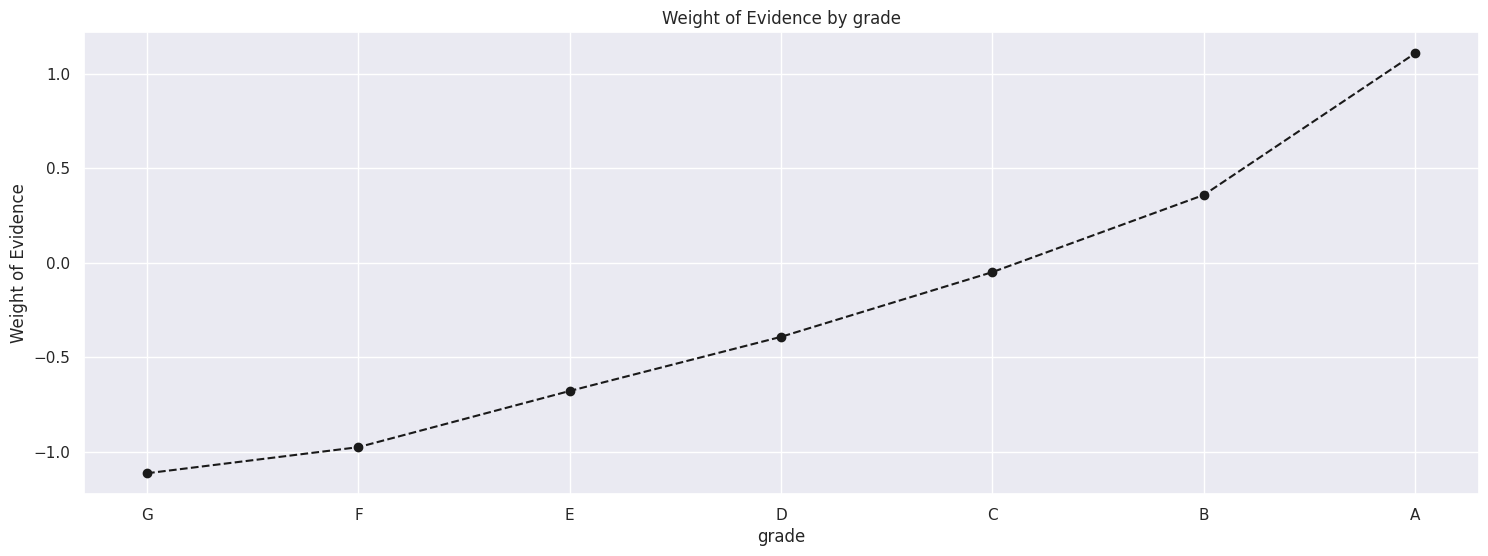

In [20]:
df_temp = woe_discrete(df_inputs_prepr, 'grade', df_targets_prepr)
print(df_temp[['grade','n_obs','prop_good','WoE','IV']])
plot_by_woe(df_temp)
# Grade is a very strong predictor - clear monotone relationship with WoE


### 1.8.2 Home Ownership

  home_ownership   n_obs  prop_good       WoE   IV
0          OTHER     137   0.795620 -0.738602  inf
1           NONE      40   0.850000 -0.363144  inf
2           RENT  150599   0.873870 -0.162123  inf
3            OWN   33295   0.892536  0.019170  inf
4       MORTGAGE  188956   0.903835  0.142834  inf
5            ANY       1   1.000000       inf  inf


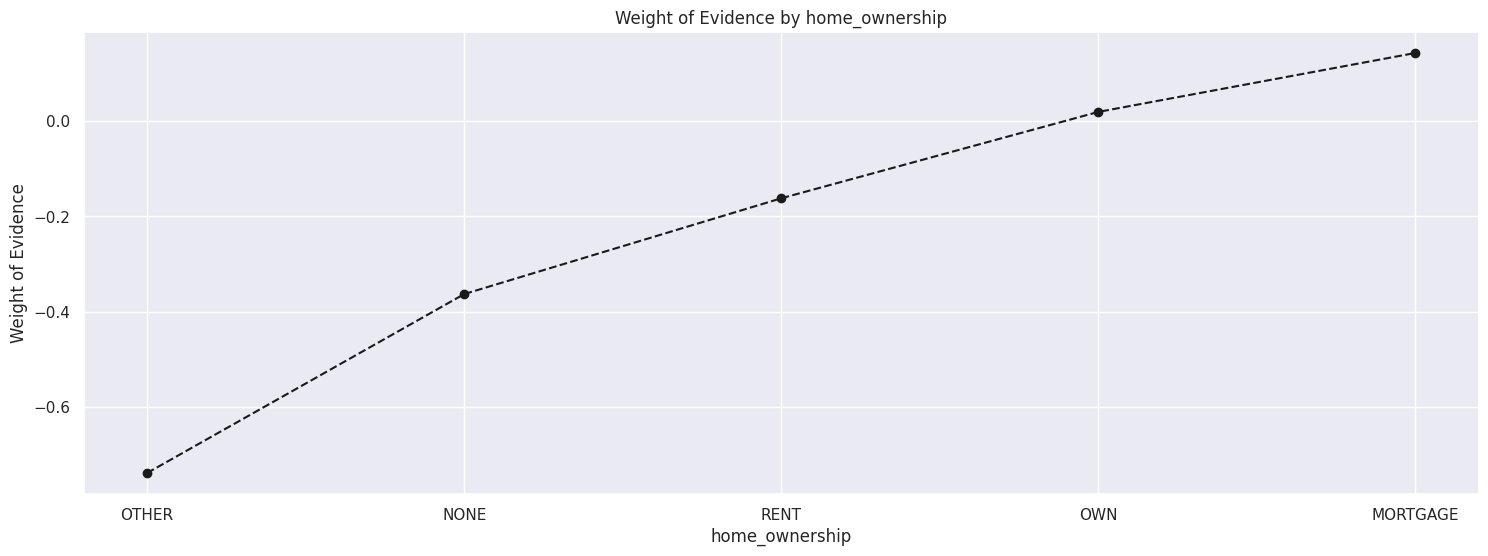

In [21]:
df_temp = woe_discrete(df_inputs_prepr, 'home_ownership', df_targets_prepr)
print(df_temp[['home_ownership','n_obs','prop_good','WoE','IV']])
plot_by_woe(df_temp)


In [22]:
# We combine RENT, OTHER, NONE, ANY into one category because:
# - They have similar risk profiles
# - Some have very few observations
df_inputs_prepr['home_ownership:RENT_OTHER_NONE_ANY'] = sum([
    df_inputs_prepr['home_ownership:RENT'],
    df_inputs_prepr['home_ownership:OTHER'],
    df_inputs_prepr['home_ownership:NONE'],
    df_inputs_prepr['home_ownership:ANY']
])
# This combined category will be our reference category
print("Combined home_ownership category created.")


Combined home_ownership category created.


### 1.8.3 Address State

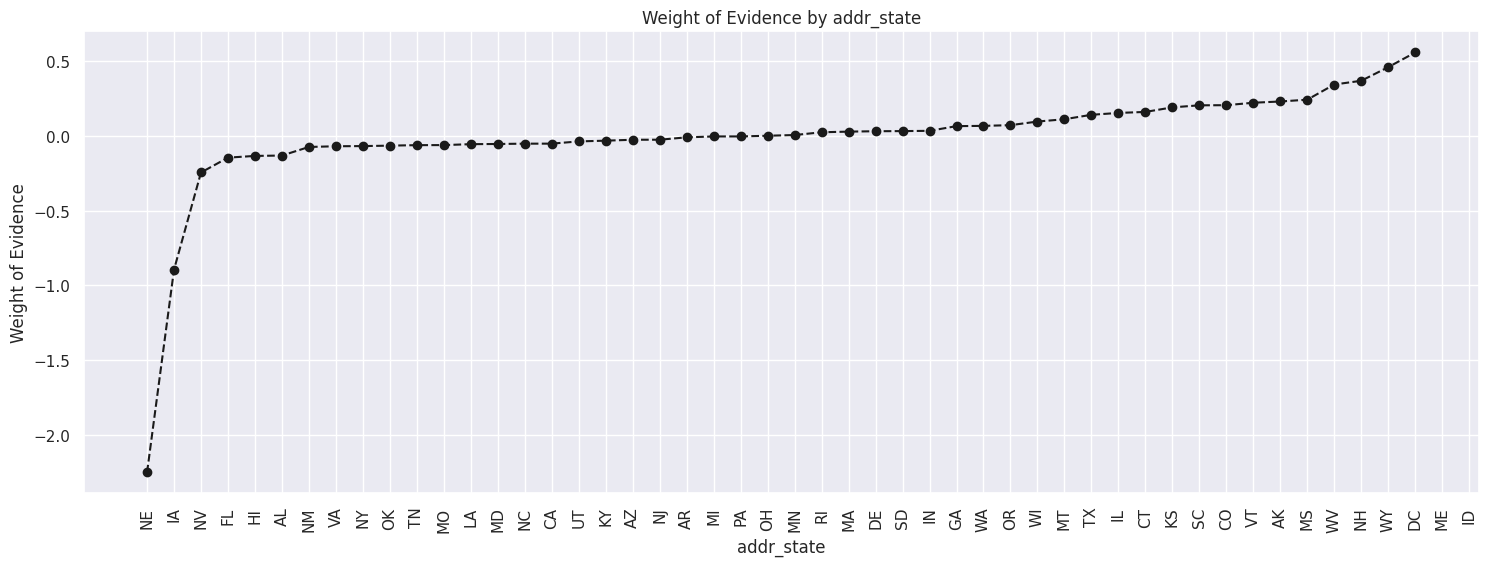

In [23]:
df_temp = woe_discrete(df_inputs_prepr, 'addr_state', df_targets_prepr)
plot_by_woe(df_temp, rotation=90)


In [24]:
# We add a dummy for ND in case it doesn't appear in training (very few observations)
if 'addr_state:ND' not in df_inputs_prepr.columns.values:
    df_inputs_prepr['addr_state:ND'] = 0

# Group states by WoE similarity (coarse classing)
df_inputs_prepr['addr_state:ND_NE_IA_NV_FL_HI_AL'] = sum([
    df_inputs_prepr['addr_state:ND'], df_inputs_prepr['addr_state:NE'],
    df_inputs_prepr['addr_state:IA'], df_inputs_prepr['addr_state:NV'],
    df_inputs_prepr['addr_state:FL'], df_inputs_prepr['addr_state:HI'],
    df_inputs_prepr['addr_state:AL']
])
df_inputs_prepr['addr_state:NM_VA'] = sum([df_inputs_prepr['addr_state:NM'], df_inputs_prepr['addr_state:VA']])
df_inputs_prepr['addr_state:OK_TN_MO_LA_MD_NC'] = sum([
    df_inputs_prepr['addr_state:OK'], df_inputs_prepr['addr_state:TN'],
    df_inputs_prepr['addr_state:MO'], df_inputs_prepr['addr_state:LA'],
    df_inputs_prepr['addr_state:MD'], df_inputs_prepr['addr_state:NC']
])
df_inputs_prepr['addr_state:UT_KY_AZ_NJ'] = sum([
    df_inputs_prepr['addr_state:UT'], df_inputs_prepr['addr_state:KY'],
    df_inputs_prepr['addr_state:AZ'], df_inputs_prepr['addr_state:NJ']
])
df_inputs_prepr['addr_state:AR_MI_PA_OH_MN'] = sum([
    df_inputs_prepr['addr_state:AR'], df_inputs_prepr['addr_state:MI'],
    df_inputs_prepr['addr_state:PA'], df_inputs_prepr['addr_state:OH'],
    df_inputs_prepr['addr_state:MN']
])
df_inputs_prepr['addr_state:RI_MA_DE_SD_IN'] = sum([
    df_inputs_prepr['addr_state:RI'], df_inputs_prepr['addr_state:MA'],
    df_inputs_prepr['addr_state:DE'], df_inputs_prepr['addr_state:SD'],
    df_inputs_prepr['addr_state:IN']
])
df_inputs_prepr['addr_state:GA_WA_OR'] = sum([
    df_inputs_prepr['addr_state:GA'], df_inputs_prepr['addr_state:WA'],
    df_inputs_prepr['addr_state:OR']
])
df_inputs_prepr['addr_state:WI_MT'] = sum([df_inputs_prepr['addr_state:WI'], df_inputs_prepr['addr_state:MT']])
df_inputs_prepr['addr_state:IL_CT'] = sum([df_inputs_prepr['addr_state:IL'], df_inputs_prepr['addr_state:CT']])
df_inputs_prepr['addr_state:KS_SC_CO_VT_AK_MS'] = sum([
    df_inputs_prepr['addr_state:KS'], df_inputs_prepr['addr_state:SC'],
    df_inputs_prepr['addr_state:CO'], df_inputs_prepr['addr_state:VT'],
    df_inputs_prepr['addr_state:AK'], df_inputs_prepr['addr_state:MS']
])
df_inputs_prepr['addr_state:WV_NH_WY_DC_ME_ID'] = sum([
    df_inputs_prepr['addr_state:WV'], df_inputs_prepr['addr_state:NH'],
    df_inputs_prepr['addr_state:WY'], df_inputs_prepr['addr_state:DC'],
    df_inputs_prepr['addr_state:ME'], df_inputs_prepr['addr_state:ID']
])
print("State groupings created.")


State groupings created.


### 1.8.4 Verification Status

  verification_status   n_obs  prop_good       WoE        IV
0            Verified  134414   0.872781 -0.171969  0.020384
1     Source Verified  120030   0.895918  0.054922  0.020384
2        Not Verified  118584   0.905679  0.164232  0.020384


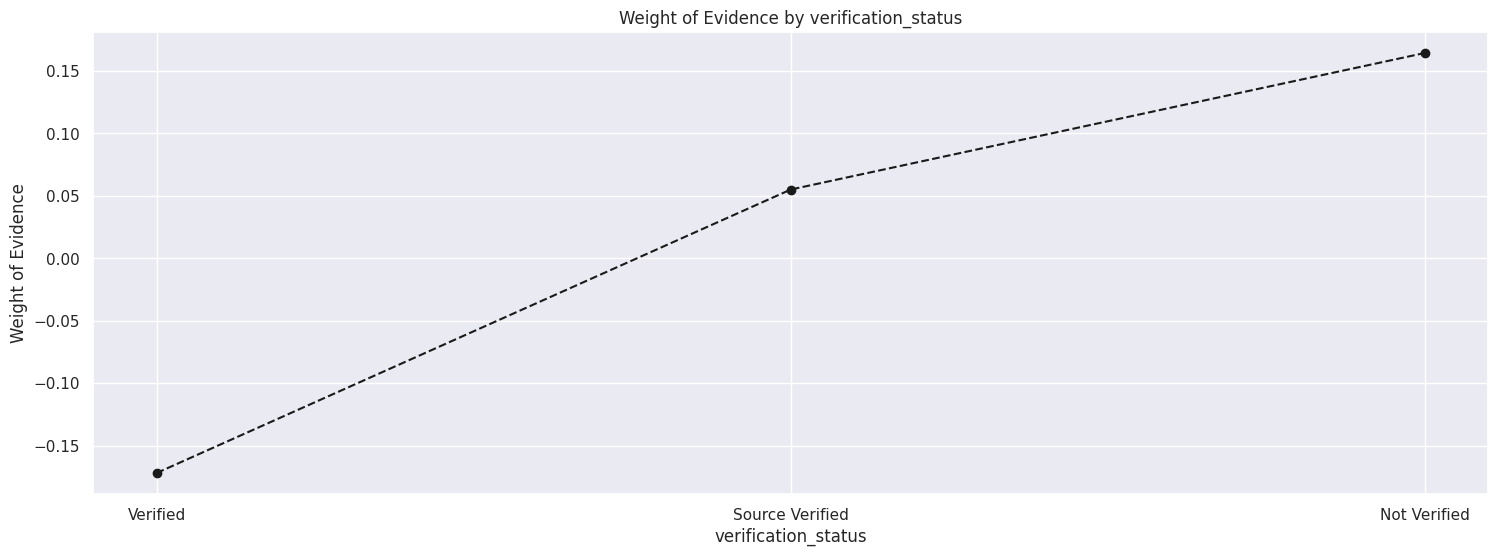

In [25]:
df_temp = woe_discrete(df_inputs_prepr, 'verification_status', df_targets_prepr)
print(df_temp[['verification_status','n_obs','prop_good','WoE','IV']])
plot_by_woe(df_temp)


### 1.8.5 Purpose

               purpose   n_obs  prop_good       WoE        IV
0       small_business    5582   0.786098 -0.796180  0.035418
1          educational     333   0.801802 -0.700151  0.035418
2               moving    2392   0.839465 -0.443493  0.035418
3                house    1830   0.860109 -0.281547  0.035418
4                other   18884   0.862264 -0.263519  0.035418
5     renewable_energy     281   0.864769 -0.242270  0.035418
6              medical    3684   0.868350 -0.211300  0.035418
7              wedding    1887   0.881823 -0.087937  0.035418
8             vacation    1991   0.882471 -0.081703  0.035418
9   debt_consolidation  219183   0.886884 -0.038440  0.035418
10    home_improvement   21238   0.900697  0.107247  0.035418
11      major_purchase    7837   0.905449  0.161541  0.035418
12                 car    4325   0.909595  0.210959  0.035418
13         credit_card   83581   0.913102  0.254371  0.035418


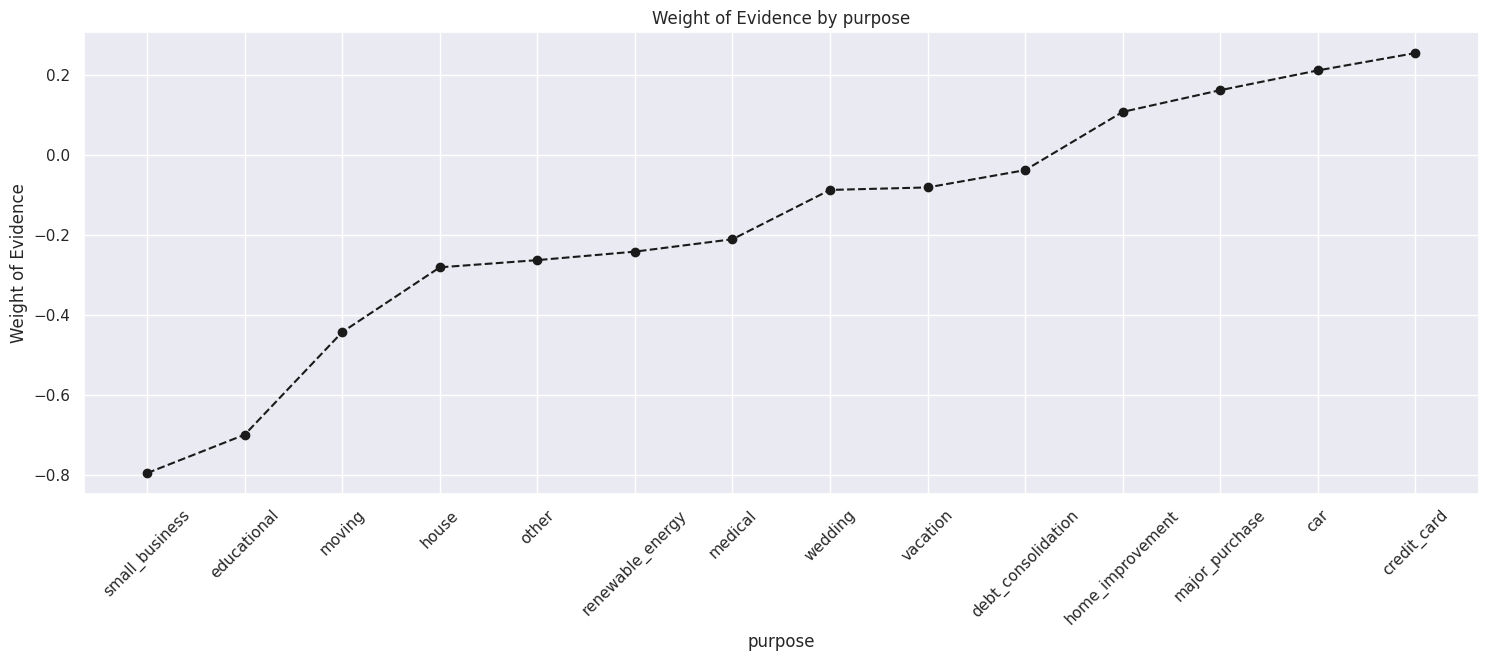

In [26]:
df_temp = woe_discrete(df_inputs_prepr, 'purpose', df_targets_prepr)
print(df_temp[['purpose','n_obs','prop_good','WoE','IV']])
plot_by_woe(df_temp, rotation=45)


In [27]:
# Group purposes by WoE
df_inputs_prepr['purpose:educ__sm_b__wedd__ren_en__mov__house'] = sum([
    df_inputs_prepr['purpose:educational'], df_inputs_prepr['purpose:small_business'],
    df_inputs_prepr['purpose:wedding'],     df_inputs_prepr['purpose:renewable_energy'],
    df_inputs_prepr['purpose:moving'],      df_inputs_prepr['purpose:house']
])
df_inputs_prepr['purpose:oth__med__vacation'] = sum([
    df_inputs_prepr['purpose:other'], df_inputs_prepr['purpose:medical'],
    df_inputs_prepr['purpose:vacation']
])
df_inputs_prepr['purpose:major_purch__car__home_impr'] = sum([
    df_inputs_prepr['purpose:major_purchase'], df_inputs_prepr['purpose:car'],
    df_inputs_prepr['purpose:home_improvement']
])
print("Purpose groupings created.")


Purpose groupings created.


### 1.8.6 Initial List Status

  initial_list_status   n_obs  prop_good       WoE       IV
0                   f  242514   0.879694 -0.108214  0.02478
1                   w  130514   0.911105  0.229461  0.02478


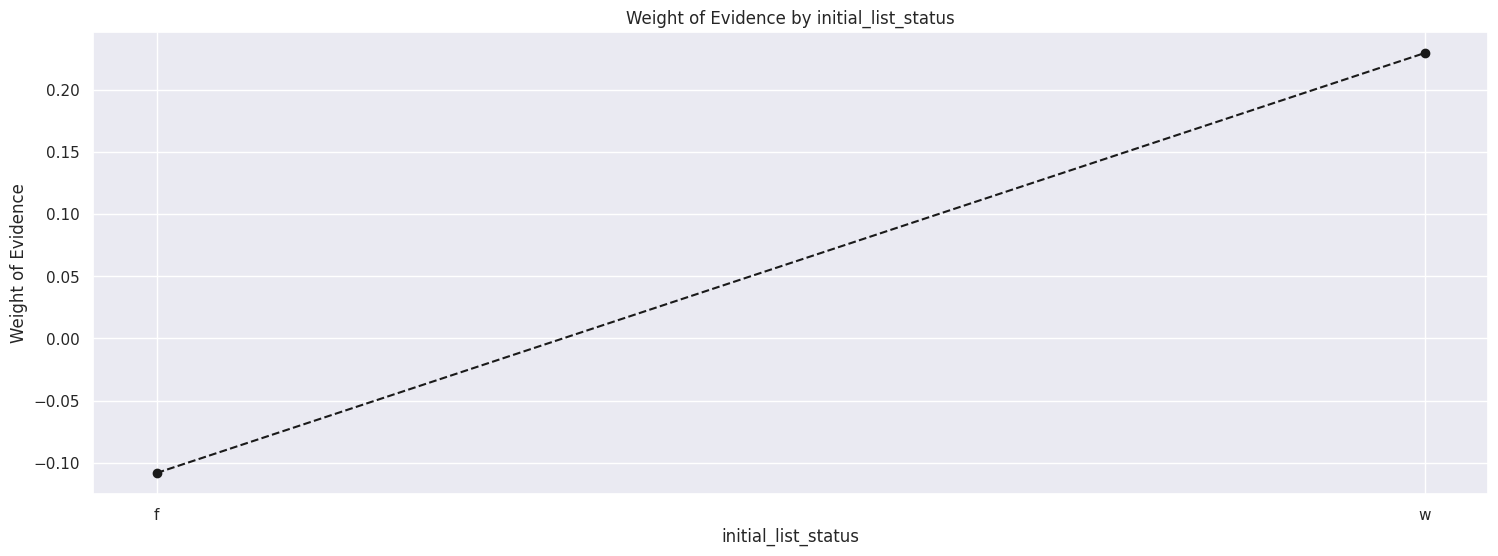

In [28]:
df_temp = woe_discrete(df_inputs_prepr, 'initial_list_status', df_targets_prepr)
print(df_temp[['initial_list_status','n_obs','prop_good','WoE','IV']])
plot_by_woe(df_temp)


### 1.8.7 Continuous Variables - Term, Employment Length, Months Since Issue, etc.

   term_int   n_obs  prop_good       WoE        IV
0        36  270419   0.902995  0.133209  0.039434
1        60  102609   0.858239 -0.297009  0.039434


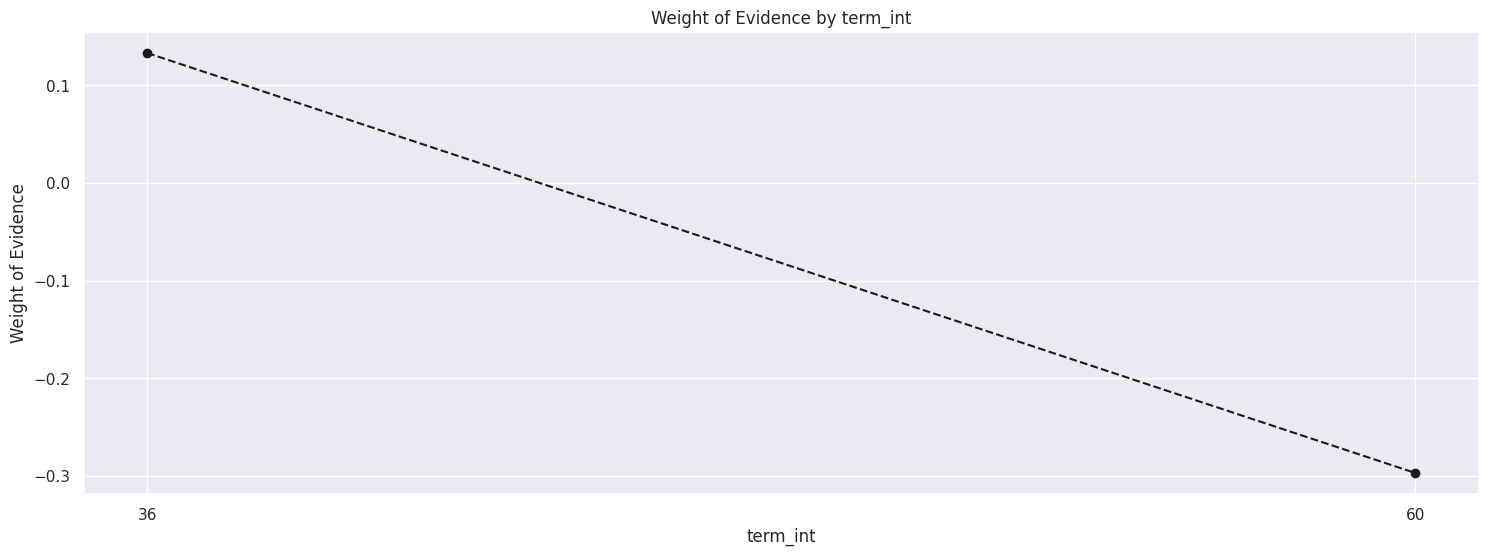

In [29]:
# Term
df_temp = woe_ordered_continuous(df_inputs_prepr, 'term_int', df_targets_prepr)
print(df_temp[['term_int','n_obs','prop_good','WoE','IV']])
plot_by_woe(df_temp)


In [30]:
# We create dummy variables for term: 36 months and 60 months
df_inputs_prepr['term:36'] = np.where(df_inputs_prepr['term_int'] == 36, 1, 0)
df_inputs_prepr['term:60'] = np.where(df_inputs_prepr['term_int'] == 60, 1, 0)
print("Term dummies created.")


Term dummies created.


    emp_length_int   n_obs  prop_good       WoE        IV
0              0.0   45720   0.876400 -0.138975  0.006506
1              1.0   23654   0.886996 -0.037329  0.006506
2              2.0   33078   0.890955  0.002785  0.006506
3              3.0   29205   0.890772  0.000907  0.006506
4              4.0   22468   0.890644 -0.000404  0.006506
5              5.0   24602   0.884725 -0.059790  0.006506
6              6.0   20887   0.883899 -0.067862  0.006506
7              7.0   21049   0.887453 -0.032759  0.006506
8              8.0   17853   0.889878 -0.008245  0.006506
9              9.0   14267   0.886662 -0.040660  0.006506
10            10.0  120245   0.900312  0.102950  0.006506


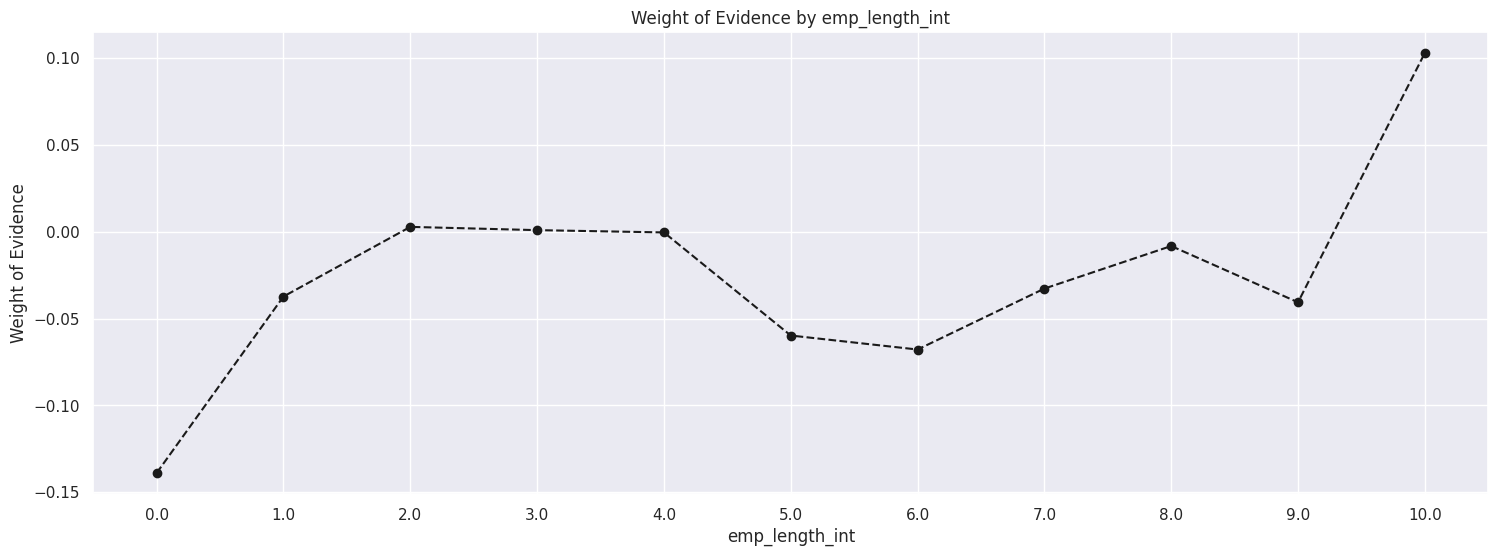

In [31]:
# Employment Length
df_temp = woe_ordered_continuous(df_inputs_prepr, 'emp_length_int', df_targets_prepr)
print(df_temp[['emp_length_int','n_obs','prop_good','WoE','IV']])
plot_by_woe(df_temp)


In [32]:
# Employment length groupings based on WoE
df_inputs_prepr['emp_length:0']    = np.where(df_inputs_prepr['emp_length_int'].between(0,0), 1, 0)
df_inputs_prepr['emp_length:1']    = np.where(df_inputs_prepr['emp_length_int'].between(1,1), 1, 0)
df_inputs_prepr['emp_length:2-4']  = np.where(df_inputs_prepr['emp_length_int'].between(2,4), 1, 0)
df_inputs_prepr['emp_length:5-6']  = np.where(df_inputs_prepr['emp_length_int'].between(5,6), 1, 0)
df_inputs_prepr['emp_length:7-9']  = np.where(df_inputs_prepr['emp_length_int'].between(7,9), 1, 0)
df_inputs_prepr['emp_length:10']   = np.where(df_inputs_prepr['emp_length_int'].between(10,10), 1, 0)
print("Employment length dummies created.")


Employment length dummies created.


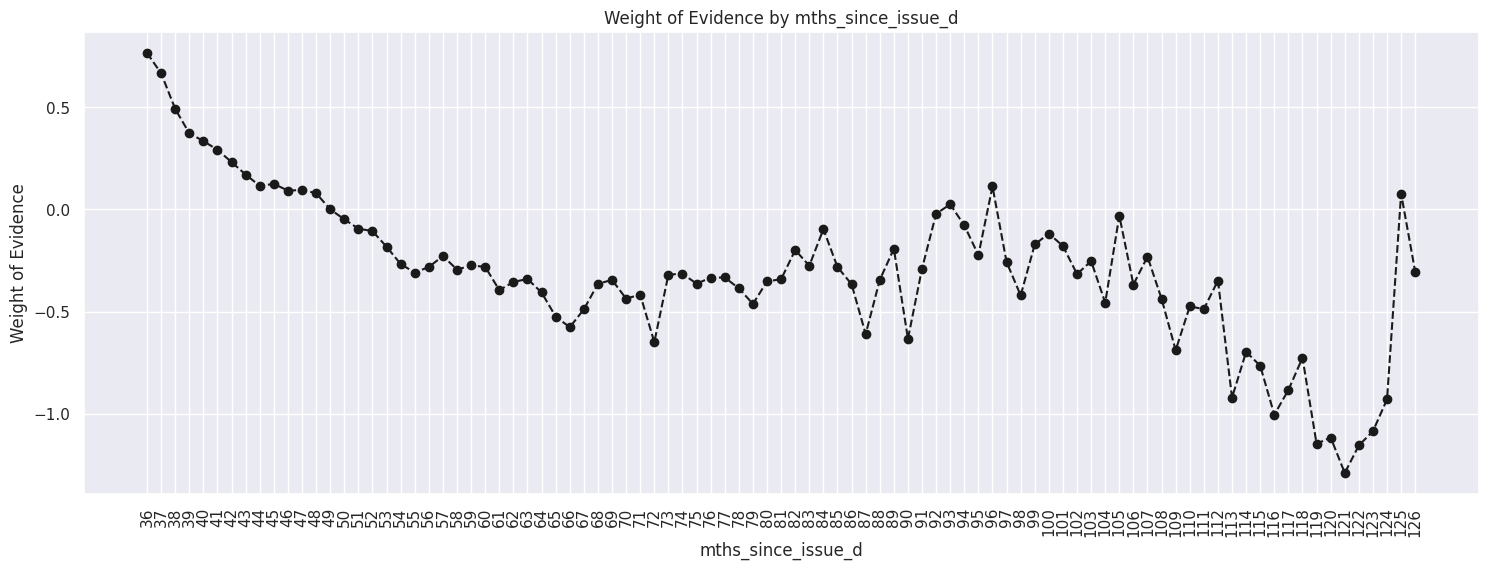

In [33]:
# Months since issue date
df_temp = woe_ordered_continuous(df_inputs_prepr, 'mths_since_issue_d', df_targets_prepr)
plot_by_woe(df_temp, rotation=90)


In [34]:
# Months since issue date - binning
df_inputs_prepr['mths_since_issue_d:<38']   = np.where(df_inputs_prepr['mths_since_issue_d'] < 38, 1, 0)
df_inputs_prepr['mths_since_issue_d:38-39'] = np.where(df_inputs_prepr['mths_since_issue_d'].between(38,39), 1, 0)
df_inputs_prepr['mths_since_issue_d:40-41'] = np.where(df_inputs_prepr['mths_since_issue_d'].between(40,41), 1, 0)
df_inputs_prepr['mths_since_issue_d:42-48'] = np.where(df_inputs_prepr['mths_since_issue_d'].between(42,48), 1, 0)
df_inputs_prepr['mths_since_issue_d:49-52'] = np.where(df_inputs_prepr['mths_since_issue_d'].between(49,52), 1, 0)
df_inputs_prepr['mths_since_issue_d:53-64'] = np.where(df_inputs_prepr['mths_since_issue_d'].between(53,64), 1, 0)
df_inputs_prepr['mths_since_issue_d:65-84'] = np.where(df_inputs_prepr['mths_since_issue_d'].between(65,84), 1, 0)
df_inputs_prepr['mths_since_issue_d:>84']   = np.where(df_inputs_prepr['mths_since_issue_d'] > 84, 1, 0)
print("Issue date bins created.")


Issue date bins created.


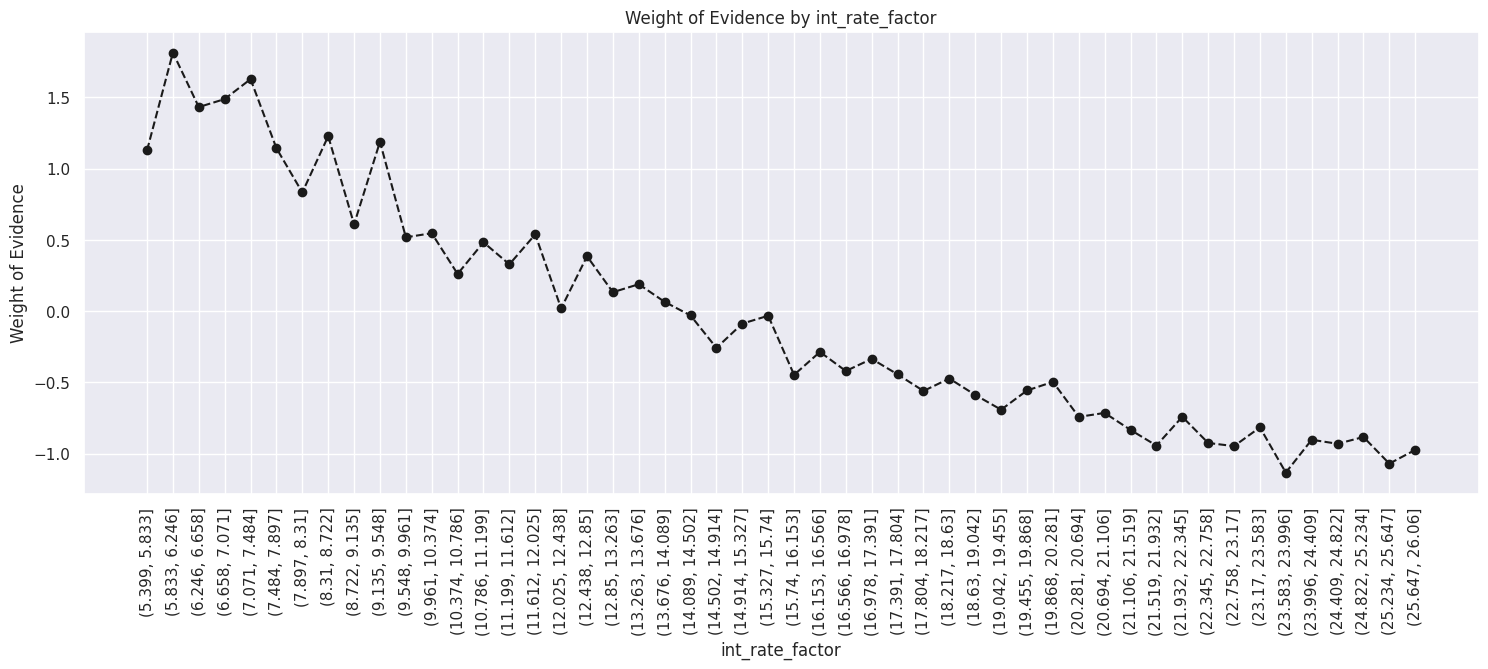

In [35]:
# Interest Rate
df_inputs_prepr['int_rate_factor'] = pd.cut(df_inputs_prepr['int_rate'], 50)
df_temp = woe_ordered_continuous(df_inputs_prepr, 'int_rate_factor', df_targets_prepr)
plot_by_woe(df_temp, rotation=90)


In [36]:
# Interest rate bins
df_inputs_prepr['int_rate:<9.548']   = np.where(df_inputs_prepr['int_rate'] <= 9.548, 1, 0)
df_inputs_prepr['int_rate:9.548-12.025'] = np.where(df_inputs_prepr['int_rate'].between(9.548,12.025), 1, 0)
df_inputs_prepr['int_rate:12.025-15.74'] = np.where(df_inputs_prepr['int_rate'].between(12.025,15.74), 1, 0)
df_inputs_prepr['int_rate:15.74-20.281'] = np.where(df_inputs_prepr['int_rate'].between(15.74,20.281), 1, 0)
df_inputs_prepr['int_rate:>20.281']  = np.where(df_inputs_prepr['int_rate'] > 20.281, 1, 0)
print("Interest rate bins created.")


Interest rate bins created.


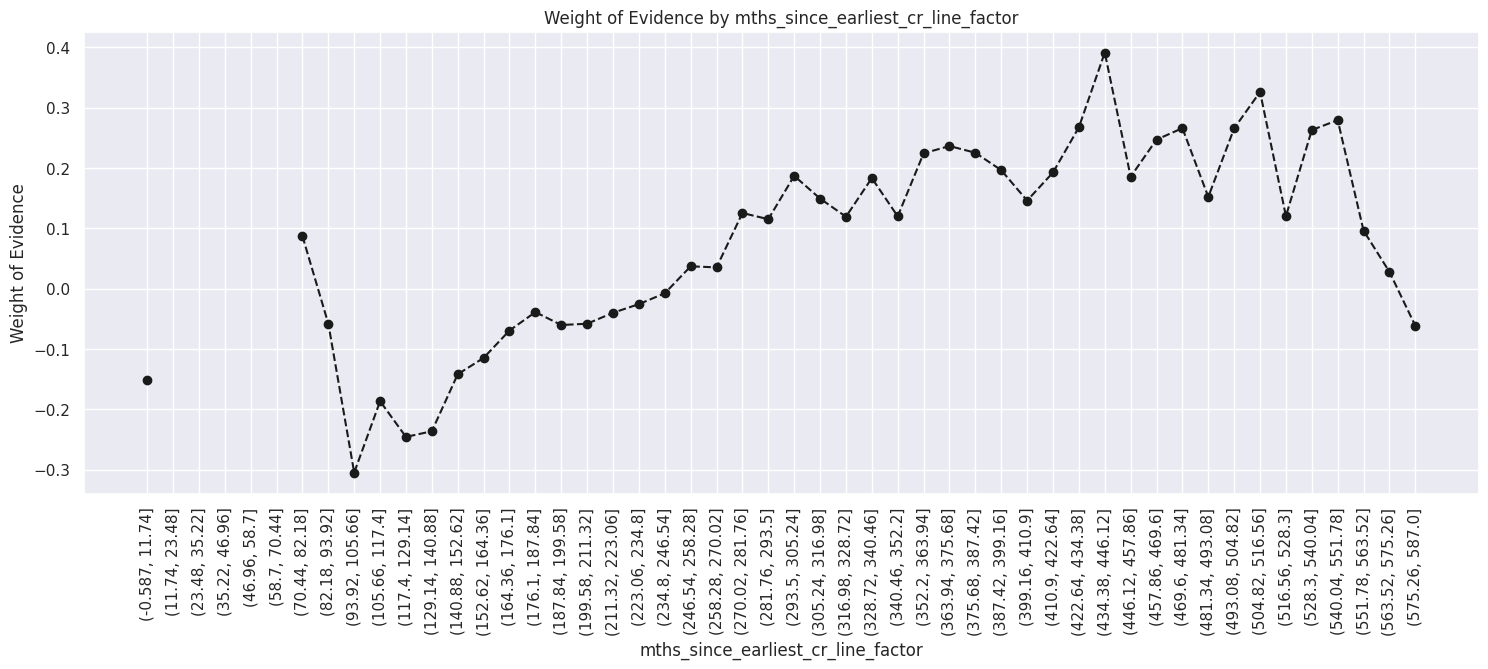

In [37]:
# Months since earliest credit line
df_inputs_prepr['mths_since_earliest_cr_line_factor'] = pd.cut(df_inputs_prepr['mths_since_earliest_cr_line'], 50)
df_temp = woe_ordered_continuous(df_inputs_prepr, 'mths_since_earliest_cr_line_factor', df_targets_prepr)
plot_by_woe(df_temp, rotation=90)


In [38]:
df_inputs_prepr['mths_since_earliest_cr_line:<140']  = np.where(df_inputs_prepr['mths_since_earliest_cr_line'] < 140, 1, 0)
df_inputs_prepr['mths_since_earliest_cr_line:141-164'] = np.where(df_inputs_prepr['mths_since_earliest_cr_line'].between(141,164), 1, 0)
df_inputs_prepr['mths_since_earliest_cr_line:165-247'] = np.where(df_inputs_prepr['mths_since_earliest_cr_line'].between(165,247), 1, 0)
df_inputs_prepr['mths_since_earliest_cr_line:>247']  = np.where(df_inputs_prepr['mths_since_earliest_cr_line'] > 247, 1, 0)
print("Credit line age bins created.")


Credit line age bins created.


In [39]:
# Delinquencies in last 2 years
df_inputs_prepr['delinq_2yrs_factor'] = pd.cut(df_inputs_prepr['delinq_2yrs'], 50)
df_temp = woe_ordered_continuous(df_inputs_prepr, 'delinq_2yrs_factor', df_targets_prepr)
print(df_temp[['delinq_2yrs_factor','n_obs','WoE','IV']].head(10))


  delinq_2yrs_factor   n_obs       WoE   IV
0     (-0.029, 0.58]  306417 -0.001898  inf
1       (0.58, 1.16]   44927  0.026622  inf
2       (1.16, 1.74]       0       NaN  inf
3       (1.74, 2.32]   13118 -0.017102  inf
4        (2.32, 2.9]       0       NaN  inf
5        (2.9, 3.48]    4550 -0.073719  inf
6       (3.48, 4.06]    1868  0.086462  inf
7       (4.06, 4.64]       0       NaN  inf
8       (4.64, 5.22]     966 -0.086357  inf
9        (5.22, 5.8]       0       NaN  inf


In [40]:
df_inputs_prepr['delinq_2yrs:0']   = np.where(df_inputs_prepr['delinq_2yrs'] == 0, 1, 0)
df_inputs_prepr['delinq_2yrs:1-3'] = np.where(df_inputs_prepr['delinq_2yrs'].between(1,3), 1, 0)
df_inputs_prepr['delinq_2yrs:>=4'] = np.where(df_inputs_prepr['delinq_2yrs'] >= 4, 1, 0)
print("Delinquency bins created.")


Delinquency bins created.


In [41]:
# Inquiries last 6 months
df_inputs_prepr['inq_last_6mths_factor'] = pd.cut(df_inputs_prepr['inq_last_6mths'], 50)
df_temp = woe_ordered_continuous(df_inputs_prepr, 'inq_last_6mths_factor', df_targets_prepr)
print(df_temp[['inq_last_6mths_factor','n_obs','WoE','IV']].head(10))


  inq_last_6mths_factor   n_obs       WoE   IV
0        (-0.033, 0.66]  193232  0.196450  inf
1          (0.66, 1.32]  104163 -0.057585  inf
2          (1.32, 1.98]       0       NaN  inf
3          (1.98, 2.64]   46214 -0.247150  inf
4           (2.64, 3.3]   20040 -0.441965  inf
5           (3.3, 3.96]       0       NaN  inf
6          (3.96, 4.62]    5810 -0.375911  inf
7          (4.62, 5.28]    2217 -0.547226  inf
8          (5.28, 5.94]       0       NaN  inf
9           (5.94, 6.6]     977 -0.784073  inf


In [42]:
df_inputs_prepr['inq_last_6mths:0']   = np.where(df_inputs_prepr['inq_last_6mths'] == 0, 1, 0)
df_inputs_prepr['inq_last_6mths:1-2'] = np.where(df_inputs_prepr['inq_last_6mths'].between(1,2), 1, 0)
df_inputs_prepr['inq_last_6mths:3-6'] = np.where(df_inputs_prepr['inq_last_6mths'].between(3,6), 1, 0)
df_inputs_prepr['inq_last_6mths:>6']  = np.where(df_inputs_prepr['inq_last_6mths'] > 6, 1, 0)
print("Inquiry bins created.")


Inquiry bins created.


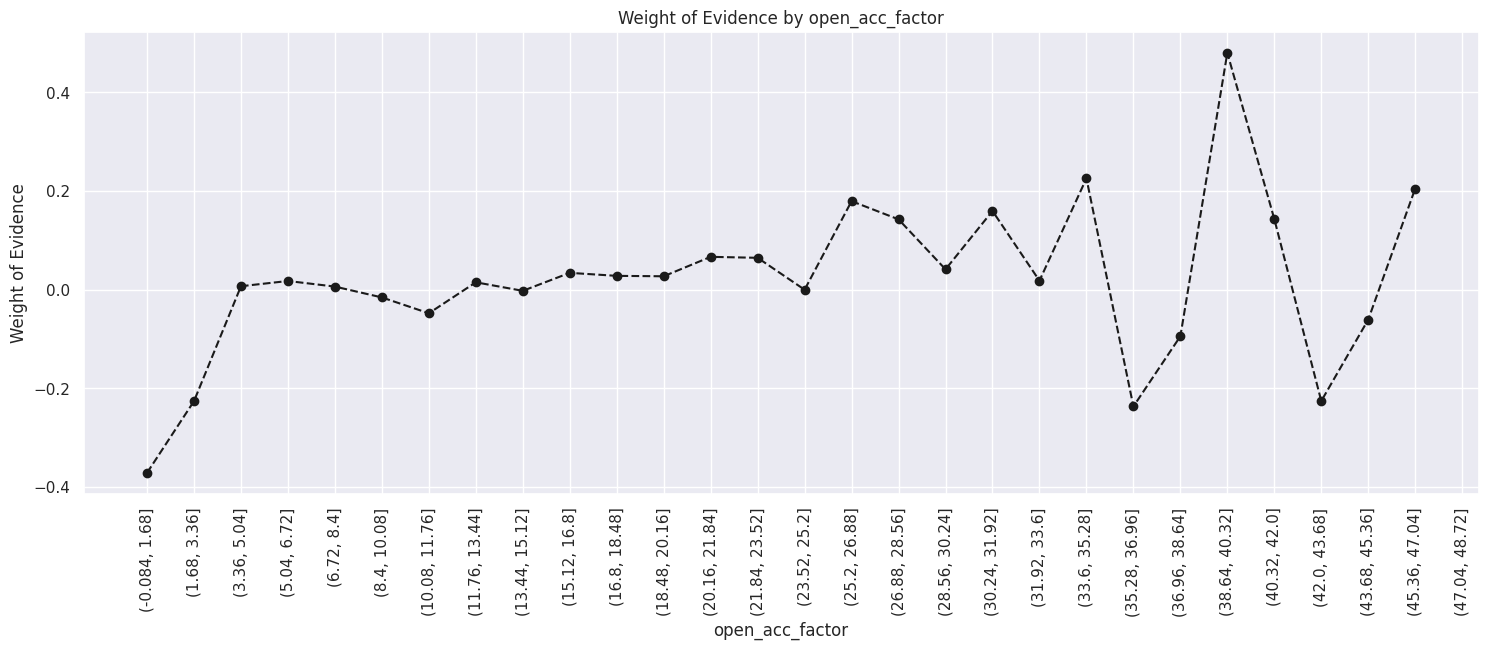

In [43]:
# Open accounts
df_inputs_prepr['open_acc_factor'] = pd.cut(df_inputs_prepr['open_acc'], 50)
df_temp = woe_ordered_continuous(df_inputs_prepr, 'open_acc_factor', df_targets_prepr)
plot_by_woe(df_temp, rotation=90)


In [44]:
df_inputs_prepr['open_acc:0']    = np.where(df_inputs_prepr['open_acc'] == 0, 1, 0)
df_inputs_prepr['open_acc:1-3']  = np.where(df_inputs_prepr['open_acc'].between(1,3), 1, 0)
df_inputs_prepr['open_acc:4-12'] = np.where(df_inputs_prepr['open_acc'].between(4,12), 1, 0)
df_inputs_prepr['open_acc:13-17']= np.where(df_inputs_prepr['open_acc'].between(13,17), 1, 0)
df_inputs_prepr['open_acc:18-22']= np.where(df_inputs_prepr['open_acc'].between(18,22), 1, 0)
df_inputs_prepr['open_acc:23-25']= np.where(df_inputs_prepr['open_acc'].between(23,25), 1, 0)
df_inputs_prepr['open_acc:26-30']= np.where(df_inputs_prepr['open_acc'].between(26,30), 1, 0)
df_inputs_prepr['open_acc:>=31'] = np.where(df_inputs_prepr['open_acc'] >= 31, 1, 0)
print("Open account bins created.")


Open account bins created.


In [45]:
# Public Records
df_inputs_prepr['pub_rec:0-2']  = np.where(df_inputs_prepr['pub_rec'].between(0,2), 1, 0)
df_inputs_prepr['pub_rec:3-4']  = np.where(df_inputs_prepr['pub_rec'].between(3,4), 1, 0)
df_inputs_prepr['pub_rec:>=5']  = np.where(df_inputs_prepr['pub_rec'] >= 5, 1, 0)
print("Public records bins created.")


Public records bins created.


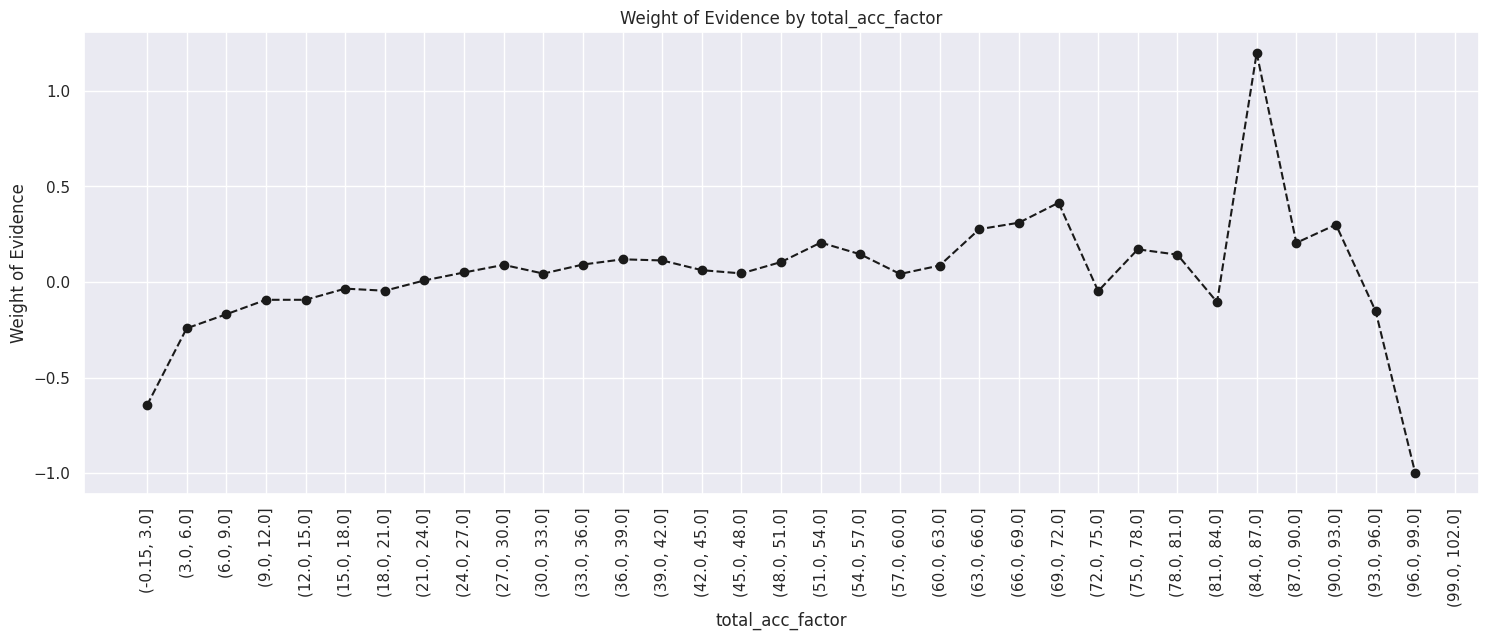

In [46]:
# Total Accounts
df_inputs_prepr['total_acc_factor'] = pd.cut(df_inputs_prepr['total_acc'], 50)
df_temp = woe_ordered_continuous(df_inputs_prepr, 'total_acc_factor', df_targets_prepr)
plot_by_woe(df_temp, rotation=90)


In [47]:
df_inputs_prepr['total_acc:<=27'] = np.where(df_inputs_prepr['total_acc'] <= 27, 1, 0)
df_inputs_prepr['total_acc:28-51']= np.where(df_inputs_prepr['total_acc'].between(28,51), 1, 0)
df_inputs_prepr['total_acc:>=52'] = np.where(df_inputs_prepr['total_acc'] >= 52, 1, 0)
print("Total account bins created.")


Total account bins created.


In [48]:
# Accounts now delinquent
df_inputs_prepr['acc_now_delinq:0'] = np.where(df_inputs_prepr['acc_now_delinq'] == 0, 1, 0)
df_inputs_prepr['acc_now_delinq:>=1']= np.where(df_inputs_prepr['acc_now_delinq'] >= 1, 1, 0)
print("Current delinquency bins created.")


Current delinquency bins created.


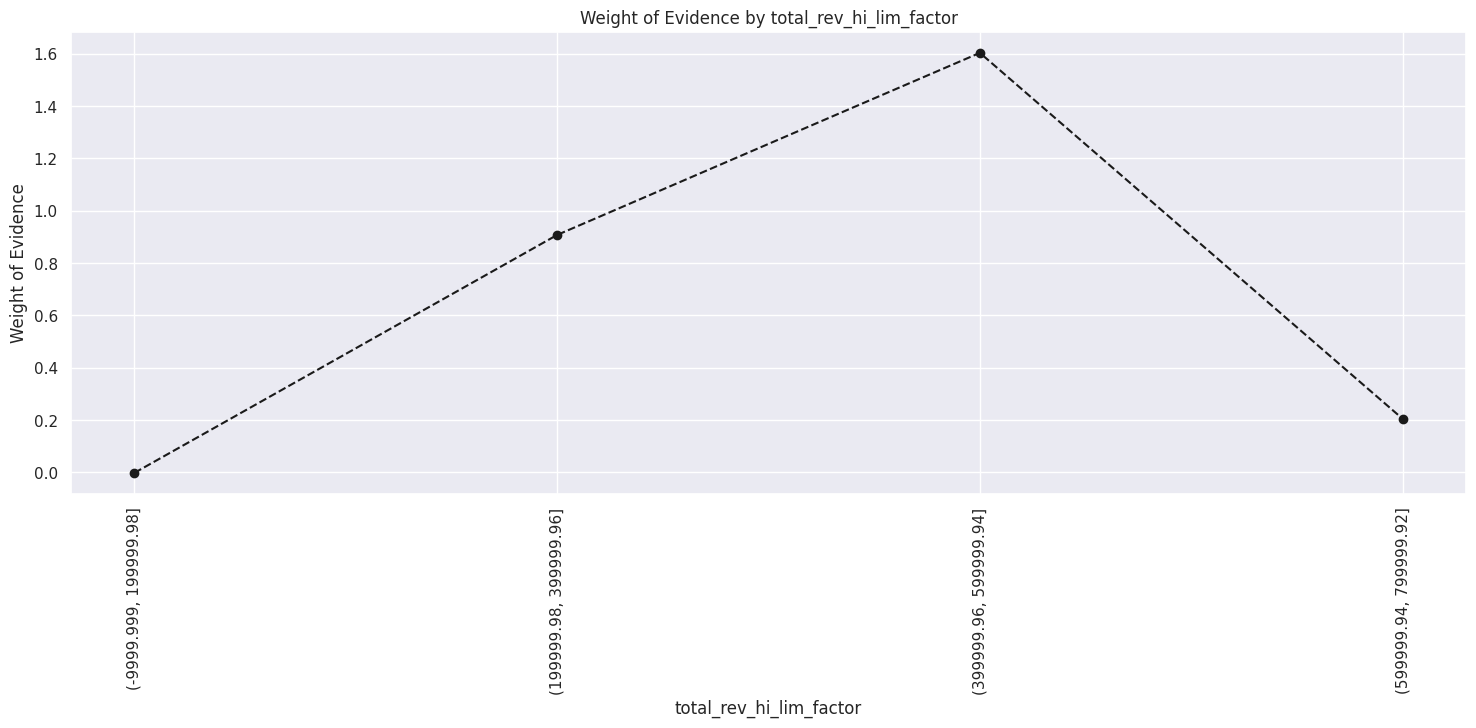

In [49]:
# Total revolving limit
df_inputs_prepr['total_rev_hi_lim_factor'] = pd.cut(df_inputs_prepr['total_rev_hi_lim'], 50)
df_temp = woe_ordered_continuous(df_inputs_prepr, 'total_rev_hi_lim_factor', df_targets_prepr)
plot_by_woe(df_temp, rotation=90)


In [50]:
df_inputs_prepr['total_rev_hi_lim:<=5K']    = np.where(df_inputs_prepr['total_rev_hi_lim'] <= 5000, 1, 0)
df_inputs_prepr['total_rev_hi_lim:5K-10K']  = np.where(df_inputs_prepr['total_rev_hi_lim'].between(5000,10000), 1, 0)
df_inputs_prepr['total_rev_hi_lim:10K-20K'] = np.where(df_inputs_prepr['total_rev_hi_lim'].between(10000,20000), 1, 0)
df_inputs_prepr['total_rev_hi_lim:20K-30K'] = np.where(df_inputs_prepr['total_rev_hi_lim'].between(20000,30000), 1, 0)
df_inputs_prepr['total_rev_hi_lim:30K-40K'] = np.where(df_inputs_prepr['total_rev_hi_lim'].between(30000,40000), 1, 0)
df_inputs_prepr['total_rev_hi_lim:40K-55K'] = np.where(df_inputs_prepr['total_rev_hi_lim'].between(40000,55000), 1, 0)
df_inputs_prepr['total_rev_hi_lim:55K-95K'] = np.where(df_inputs_prepr['total_rev_hi_lim'].between(55000,95000), 1, 0)
df_inputs_prepr['total_rev_hi_lim:>95K']    = np.where(df_inputs_prepr['total_rev_hi_lim'] > 95000, 1, 0)
print("Revolving limit bins created.")


Revolving limit bins created.


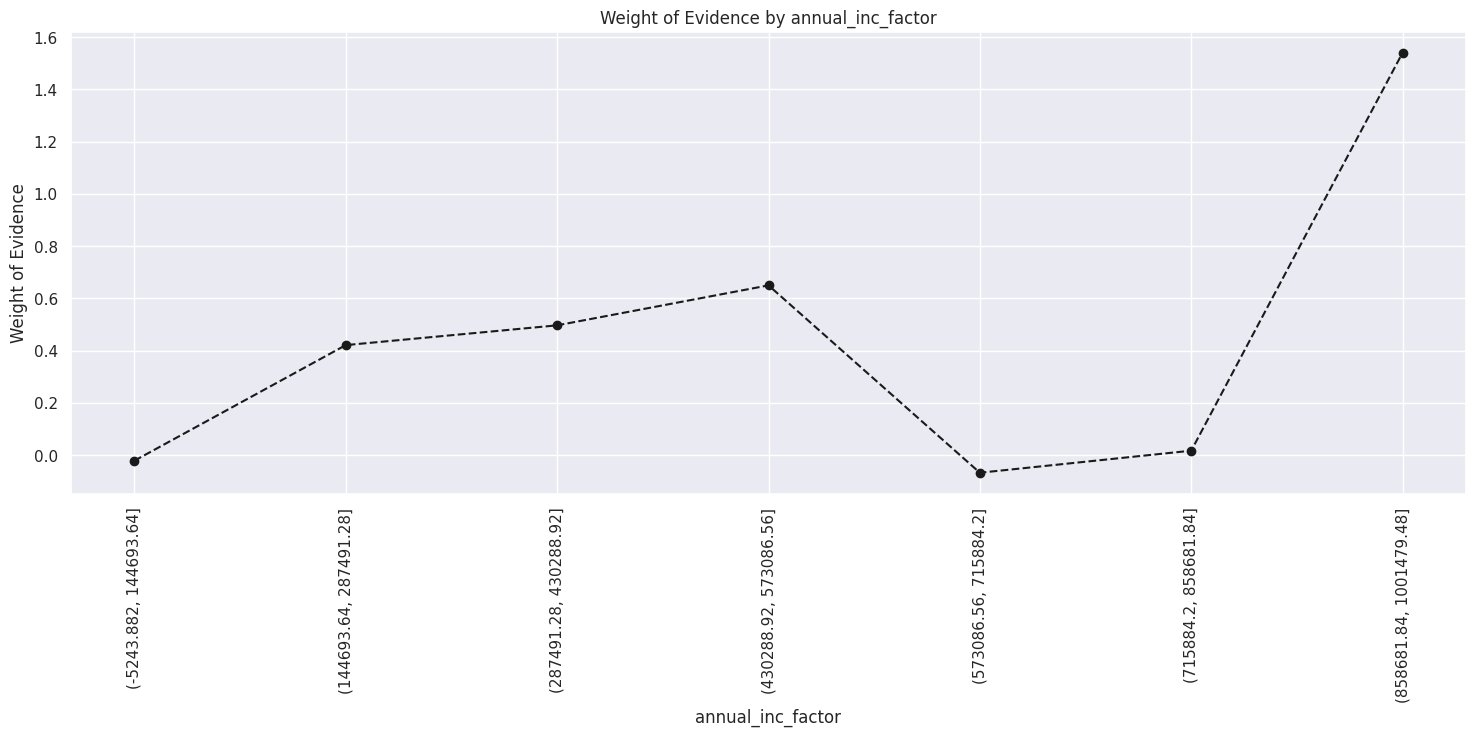

In [51]:
# Annual Income
df_inputs_prepr['annual_inc_factor'] = pd.cut(df_inputs_prepr['annual_inc'], 50)
df_temp = woe_ordered_continuous(df_inputs_prepr, 'annual_inc_factor', df_targets_prepr)
plot_by_woe(df_temp, rotation=90)


In [52]:
df_inputs_prepr['annual_inc:<20K']    = np.where(df_inputs_prepr['annual_inc'] < 20000, 1, 0)
df_inputs_prepr['annual_inc:20K-30K'] = np.where(df_inputs_prepr['annual_inc'].between(20000,30000), 1, 0)
df_inputs_prepr['annual_inc:30K-40K'] = np.where(df_inputs_prepr['annual_inc'].between(30000,40000), 1, 0)
df_inputs_prepr['annual_inc:40K-50K'] = np.where(df_inputs_prepr['annual_inc'].between(40000,50000), 1, 0)
df_inputs_prepr['annual_inc:50K-60K'] = np.where(df_inputs_prepr['annual_inc'].between(50000,60000), 1, 0)
df_inputs_prepr['annual_inc:60K-70K'] = np.where(df_inputs_prepr['annual_inc'].between(60000,70000), 1, 0)
df_inputs_prepr['annual_inc:70K-80K'] = np.where(df_inputs_prepr['annual_inc'].between(70000,80000), 1, 0)
df_inputs_prepr['annual_inc:80K-90K'] = np.where(df_inputs_prepr['annual_inc'].between(80000,90000), 1, 0)
df_inputs_prepr['annual_inc:90K-100K']= np.where(df_inputs_prepr['annual_inc'].between(90000,100000), 1, 0)
df_inputs_prepr['annual_inc:100K-120K']=np.where(df_inputs_prepr['annual_inc'].between(100000,120000), 1, 0)
df_inputs_prepr['annual_inc:120K-140K']=np.where(df_inputs_prepr['annual_inc'].between(120000,140000), 1, 0)
df_inputs_prepr['annual_inc:>140K']   = np.where(df_inputs_prepr['annual_inc'] > 140000, 1, 0)
print("Annual income bins created.")


Annual income bins created.


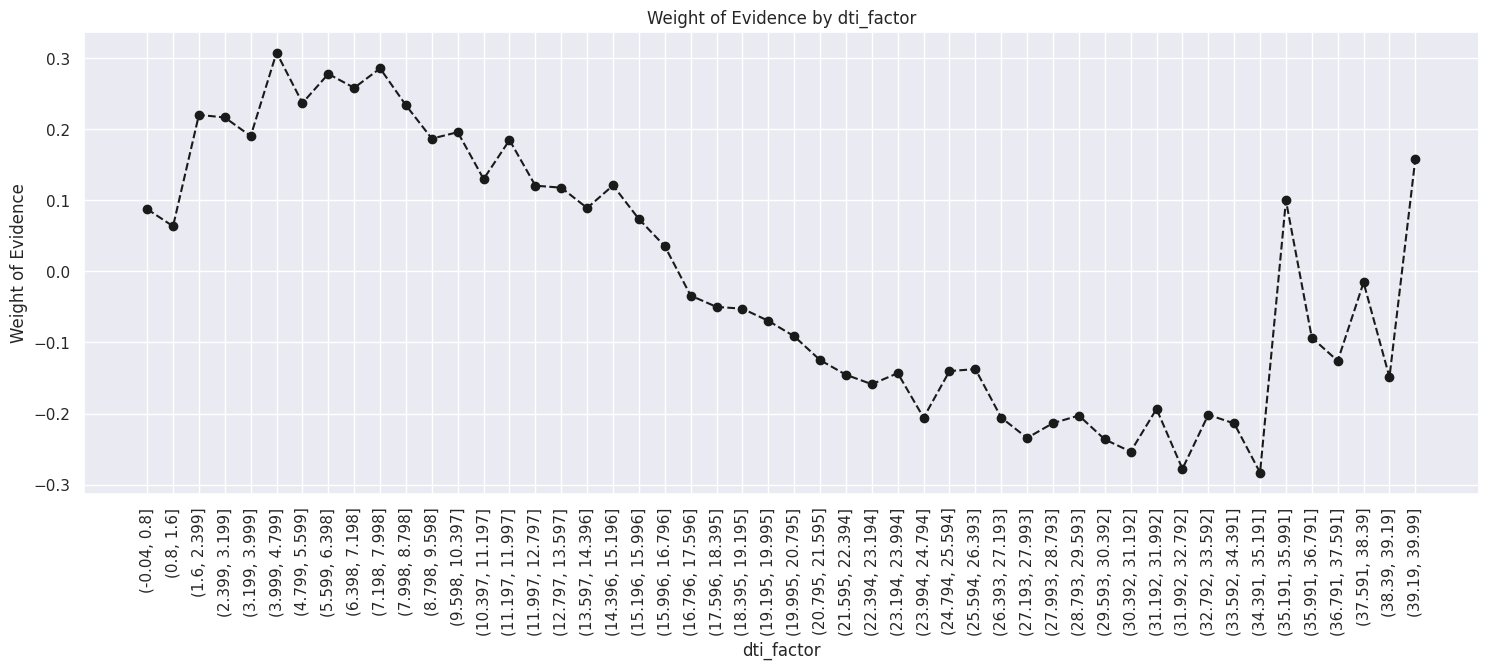

In [53]:
# DTI (Debt-to-Income ratio)
df_inputs_prepr['dti_factor'] = pd.cut(df_inputs_prepr['dti'], 50)
df_temp = woe_ordered_continuous(df_inputs_prepr, 'dti_factor', df_targets_prepr)
plot_by_woe(df_temp, rotation=90)


In [54]:
df_inputs_prepr['dti:<=1.4']   = np.where(df_inputs_prepr['dti'] <= 1.4, 1, 0)
df_inputs_prepr['dti:1.4-3.5'] = np.where(df_inputs_prepr['dti'].between(1.4,3.5), 1, 0)
df_inputs_prepr['dti:3.5-7.7'] = np.where(df_inputs_prepr['dti'].between(3.5,7.7), 1, 0)
df_inputs_prepr['dti:7.7-10.5']= np.where(df_inputs_prepr['dti'].between(7.7,10.5), 1, 0)
df_inputs_prepr['dti:10.5-16.1']=np.where(df_inputs_prepr['dti'].between(10.5,16.1), 1, 0)
df_inputs_prepr['dti:16.1-20.3']=np.where(df_inputs_prepr['dti'].between(16.1,20.3), 1, 0)
df_inputs_prepr['dti:20.3-21.7']=np.where(df_inputs_prepr['dti'].between(20.3,21.7), 1, 0)
df_inputs_prepr['dti:21.7-22.4']=np.where(df_inputs_prepr['dti'].between(21.7,22.4), 1, 0)
df_inputs_prepr['dti:22.4-35']  =np.where(df_inputs_prepr['dti'].between(22.4,35), 1, 0)
df_inputs_prepr['dti:>35']      = np.where(df_inputs_prepr['dti'] > 35, 1, 0)
print("DTI bins created.")


DTI bins created.


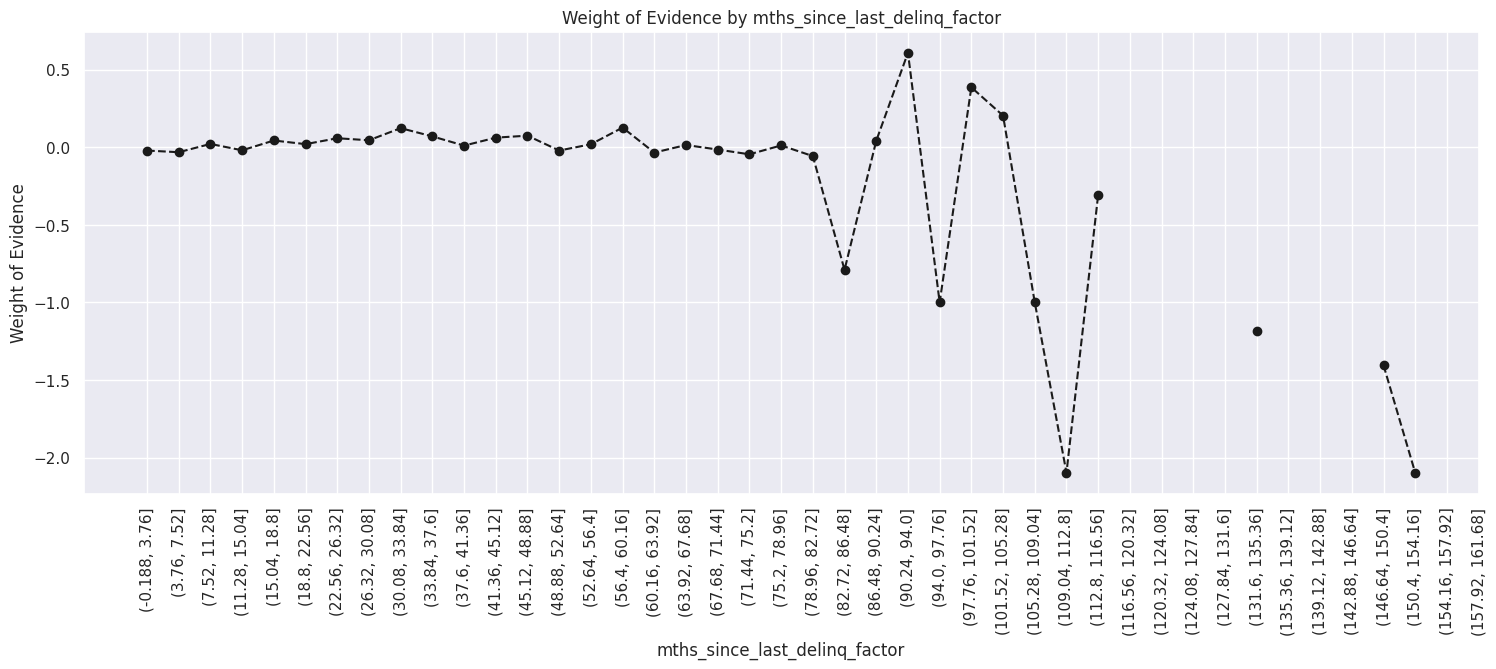

In [55]:
# Months since last delinquency
loan_data['mths_since_last_delinq'].fillna(0, inplace=True)
df_inputs_prepr['mths_since_last_delinq'].fillna(0, inplace=True)

df_inputs_prepr['mths_since_last_delinq_factor'] = pd.cut(df_inputs_prepr['mths_since_last_delinq'], 50)
df_temp = woe_ordered_continuous(df_inputs_prepr, 'mths_since_last_delinq_factor', df_targets_prepr)
plot_by_woe(df_temp, rotation=90)


In [56]:
df_inputs_prepr['mths_since_last_delinq:0-3']   = np.where(df_inputs_prepr['mths_since_last_delinq'].between(0,3), 1, 0)
df_inputs_prepr['mths_since_last_delinq:4-30']  = np.where(df_inputs_prepr['mths_since_last_delinq'].between(4,30), 1, 0)
df_inputs_prepr['mths_since_last_delinq:31-56'] = np.where(df_inputs_prepr['mths_since_last_delinq'].between(31,56), 1, 0)
df_inputs_prepr['mths_since_last_delinq:>=57']  = np.where(df_inputs_prepr['mths_since_last_delinq'] >= 57, 1, 0)
print("Last delinquency bins created.")


Last delinquency bins created.


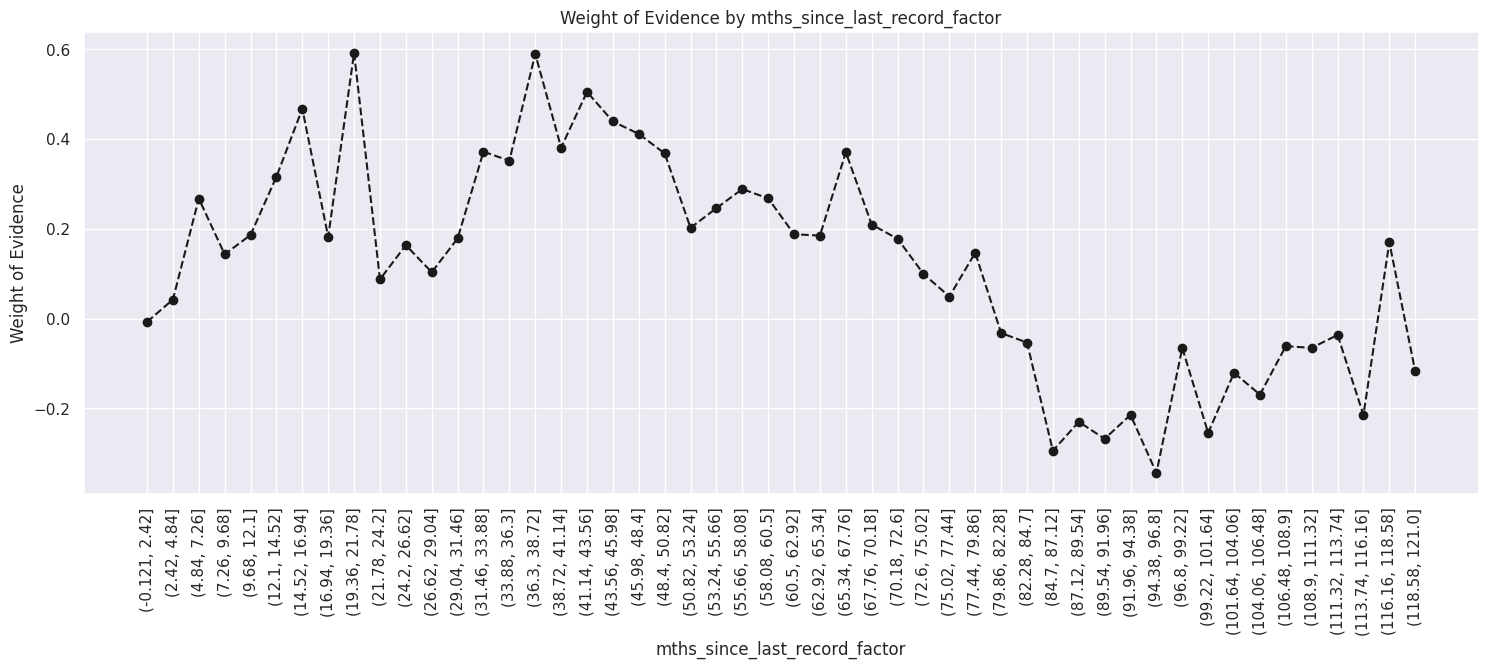

In [57]:
# Months since last public record
loan_data['mths_since_last_record'].fillna(0, inplace=True)
df_inputs_prepr['mths_since_last_record'].fillna(0, inplace=True)

df_inputs_prepr['mths_since_last_record_factor'] = pd.cut(df_inputs_prepr['mths_since_last_record'], 50)
df_temp = woe_ordered_continuous(df_inputs_prepr, 'mths_since_last_record_factor', df_targets_prepr)
plot_by_woe(df_temp, rotation=90)


In [58]:
df_inputs_prepr['mths_since_last_record:0-2']   = np.where(df_inputs_prepr['mths_since_last_record'].between(0,2), 1, 0)
df_inputs_prepr['mths_since_last_record:3-20']  = np.where(df_inputs_prepr['mths_since_last_record'].between(3,20), 1, 0)
df_inputs_prepr['mths_since_last_record:21-31'] = np.where(df_inputs_prepr['mths_since_last_record'].between(21,31), 1, 0)
df_inputs_prepr['mths_since_last_record:32-80'] = np.where(df_inputs_prepr['mths_since_last_record'].between(32,80), 1, 0)
df_inputs_prepr['mths_since_last_record:81-86'] = np.where(df_inputs_prepr['mths_since_last_record'].between(81,86), 1, 0)
df_inputs_prepr['mths_since_last_record:>=87']  = np.where(df_inputs_prepr['mths_since_last_record'] >= 87, 1, 0)
print("Last public record bins created.")
print("\n✅ All WoE binning complete! Data is ready for PD model.")


Last public record bins created.

✅ All WoE binning complete! Data is ready for PD model.


---
# Section 2: Probability of Default (PD) Model

## 2.1 Select Features for PD Model

In [59]:
# These are all the WoE-encoded dummy variables we are using
features_all = [
    'grade:A', 'grade:B', 'grade:C', 'grade:D', 'grade:E', 'grade:F', 'grade:G',
    'home_ownership:RENT_OTHER_NONE_ANY', 'home_ownership:OWN', 'home_ownership:MORTGAGE',
    'addr_state:ND_NE_IA_NV_FL_HI_AL', 'addr_state:NM_VA', 'addr_state:NY',
    'addr_state:OK_TN_MO_LA_MD_NC', 'addr_state:CA', 'addr_state:UT_KY_AZ_NJ',
    'addr_state:AR_MI_PA_OH_MN', 'addr_state:RI_MA_DE_SD_IN', 'addr_state:GA_WA_OR',
    'addr_state:WI_MT', 'addr_state:TX', 'addr_state:IL_CT', 'addr_state:KS_SC_CO_VT_AK_MS',
    'addr_state:WV_NH_WY_DC_ME_ID',
    'verification_status:Not Verified', 'verification_status:Source Verified', 'verification_status:Verified',
    'purpose:educ__sm_b__wedd__ren_en__mov__house', 'purpose:credit_card',
    'purpose:debt_consolidation', 'purpose:oth__med__vacation', 'purpose:major_purch__car__home_impr',
    'initial_list_status:f', 'initial_list_status:w',
    'term:36', 'term:60',
    'emp_length:0', 'emp_length:1', 'emp_length:2-4', 'emp_length:5-6', 'emp_length:7-9', 'emp_length:10',
    'mths_since_issue_d:<38', 'mths_since_issue_d:38-39', 'mths_since_issue_d:40-41',
    'mths_since_issue_d:42-48', 'mths_since_issue_d:49-52', 'mths_since_issue_d:53-64',
    'mths_since_issue_d:65-84', 'mths_since_issue_d:>84',
    'int_rate:<9.548', 'int_rate:9.548-12.025', 'int_rate:12.025-15.74',
    'int_rate:15.74-20.281', 'int_rate:>20.281',
    'mths_since_earliest_cr_line:<140', 'mths_since_earliest_cr_line:141-164',
    'mths_since_earliest_cr_line:165-247', 'mths_since_earliest_cr_line:>247',
    'delinq_2yrs:0', 'delinq_2yrs:1-3', 'delinq_2yrs:>=4',
    'inq_last_6mths:0', 'inq_last_6mths:1-2', 'inq_last_6mths:3-6', 'inq_last_6mths:>6',
    'open_acc:0', 'open_acc:1-3', 'open_acc:4-12', 'open_acc:13-17', 'open_acc:18-22',
    'open_acc:23-25', 'open_acc:26-30', 'open_acc:>=31',
    'pub_rec:0-2', 'pub_rec:3-4', 'pub_rec:>=5',
    'total_acc:<=27', 'total_acc:28-51', 'total_acc:>=52',
    'acc_now_delinq:0', 'acc_now_delinq:>=1',
    'total_rev_hi_lim:<=5K', 'total_rev_hi_lim:5K-10K', 'total_rev_hi_lim:10K-20K',
    'total_rev_hi_lim:20K-30K', 'total_rev_hi_lim:30K-40K', 'total_rev_hi_lim:40K-55K',
    'total_rev_hi_lim:55K-95K', 'total_rev_hi_lim:>95K',
    'annual_inc:<20K', 'annual_inc:20K-30K', 'annual_inc:30K-40K', 'annual_inc:40K-50K',
    'annual_inc:50K-60K', 'annual_inc:60K-70K', 'annual_inc:70K-80K', 'annual_inc:80K-90K',
    'annual_inc:90K-100K', 'annual_inc:100K-120K', 'annual_inc:120K-140K', 'annual_inc:>140K',
    'dti:<=1.4', 'dti:1.4-3.5', 'dti:3.5-7.7', 'dti:7.7-10.5', 'dti:10.5-16.1',
    'dti:16.1-20.3', 'dti:20.3-21.7', 'dti:21.7-22.4', 'dti:22.4-35', 'dti:>35',
    'mths_since_last_delinq:0-3', 'mths_since_last_delinq:4-30',
    'mths_since_last_delinq:31-56', 'mths_since_last_delinq:>=57',
    'mths_since_last_record:0-2', 'mths_since_last_record:3-20', 'mths_since_last_record:21-31',
    'mths_since_last_record:32-80', 'mths_since_last_record:81-86', 'mths_since_last_record:>=87',
]

# Reference categories - we drop one dummy per variable to avoid multicollinearity
ref_categories = [
    'grade:G', 'home_ownership:RENT_OTHER_NONE_ANY', 'addr_state:ND_NE_IA_NV_FL_HI_AL',
    'verification_status:Verified', 'purpose:educ__sm_b__wedd__ren_en__mov__house',
    'initial_list_status:f', 'term:60', 'emp_length:0', 'mths_since_issue_d:>84',
    'int_rate:>20.281', 'mths_since_earliest_cr_line:<140', 'delinq_2yrs:>=4',
    'inq_last_6mths:>6', 'open_acc:0', 'pub_rec:0-2', 'total_acc:<=27',
    'acc_now_delinq:0', 'total_rev_hi_lim:<=5K', 'annual_inc:<20K', 'dti:>35',
    'mths_since_last_delinq:0-3', 'mths_since_last_record:0-2',
]

inputs_train_with_ref_cat = df_inputs_prepr.loc[:, features_all]
inputs_train = inputs_train_with_ref_cat.drop(ref_categories, axis=1)
print(f"Features used for PD model: {inputs_train.shape[1]}")


Features used for PD model: 100


## 2.2 Logistic Regression with P-Values

In [61]:
# We are building a custom Logistic Regression class that also shows p-values
# P-values tell us which variables are statistically significant

class LogisticRegression_with_p_values:
    def __init__(self, *args, **kwargs):
        self.model = linear_model.LogisticRegression(*args, **kwargs)

    def fit(self, X, y):
        self.model.fit(X, y)
        # Calculate p-values using Fisher Information Matrix
        X = np.asarray(X, dtype=np.float64) # Ensure X is a float64 numpy array
        denom = (2.0 * (1.0 + np.cosh(self.model.decision_function(X))))
        denom = np.tile(denom, (X.shape[1], 1)).T
        F_ij = np.dot((X / denom).T, X)
        Cramer_Rao = np.linalg.inv(F_ij)
        sigma_estimates = np.sqrt(np.diagonal(Cramer_Rao))
        z_scores = self.model.coef_[0] / sigma_estimates
        p_values = [stat.norm.sf(abs(x)) * 2 for x in z_scores]
        self.coef_ = self.model.coef_
        self.intercept_ = self.model.intercept_
        self.p_values = p_values

reg = LogisticRegression_with_p_values()
reg.fit(inputs_train, loan_data_targets_train)
print("Model fitted successfully.")

Model fitted successfully.


In [62]:
# Display coefficients and p-values
feature_name = inputs_train.columns.values
summary_table = pd.DataFrame(columns=['Feature name'], data=feature_name)
summary_table['Coefficients'] = np.transpose(reg.coef_)
summary_table.index = summary_table.index + 1
summary_table.loc[0] = ['Intercept', reg.intercept_[0]]
summary_table = summary_table.sort_index()

p_values = np.append(np.nan, np.array(reg.p_values))
summary_table['p_values'] = p_values.round(3)
summary_table


,Feature name,Coefficients,p_values
0,Intercept,-0.258438,NaN
1,grade:A,0.988321,0.000
2,grade:B,0.782561,0.000
3,grade:C,0.590804,0.000
4,grade:D,0.408448,0.000
...,...,...,...
96,mths_since_last_record:3-20,0.112288,0.231
97,mths_since_last_record:21-31,0.031982,0.684
98,mths_since_last_record:32-80,0.188056,0.000
99,mths_since_last_record:81-86,-0.146658,0.019


## 2.3 Evaluating the PD Model

We evaluate using:
- **ROC AUC** - Area Under the ROC Curve. Perfect model = 1.0, random = 0.5
- **Gini Coefficient** - `2 × AUC − 1`. Industry standard for scorecards
- **KS Statistic** - Maximum separation between good and bad score distributions


In [63]:
# Apply same preprocessing to test data
df_inputs_prepr_test = loan_data_inputs_test

# Apply all the same transformations to test set
# Home Ownership
df_inputs_prepr_test['home_ownership:RENT_OTHER_NONE_ANY'] = sum([
    df_inputs_prepr_test['home_ownership:RENT'], df_inputs_prepr_test['home_ownership:OTHER'],
    df_inputs_prepr_test['home_ownership:NONE'], df_inputs_prepr_test['home_ownership:ANY']
])

# Fill missing in test
loan_data_inputs_test['mths_since_last_delinq'].fillna(0, inplace=True)
loan_data_inputs_test['mths_since_last_record'].fillna(0, inplace=True)

# addr_state — handle missing states in test
if 'addr_state:ND' not in df_inputs_prepr_test.columns.values:
    df_inputs_prepr_test['addr_state:ND'] = 0

# All state groups
for col, states in [
    ('addr_state:ND_NE_IA_NV_FL_HI_AL', ['addr_state:ND','addr_state:NE','addr_state:IA','addr_state:NV','addr_state:FL','addr_state:HI','addr_state:AL']),
    ('addr_state:NM_VA', ['addr_state:NM','addr_state:VA']),
    ('addr_state:OK_TN_MO_LA_MD_NC', ['addr_state:OK','addr_state:TN','addr_state:MO','addr_state:LA','addr_state:MD','addr_state:NC']),
    ('addr_state:UT_KY_AZ_NJ', ['addr_state:UT','addr_state:KY','addr_state:AZ','addr_state:NJ']),
    ('addr_state:AR_MI_PA_OH_MN', ['addr_state:AR','addr_state:MI','addr_state:PA','addr_state:OH','addr_state:MN']),
    ('addr_state:RI_MA_DE_SD_IN', ['addr_state:RI','addr_state:MA','addr_state:DE','addr_state:SD','addr_state:IN']),
    ('addr_state:GA_WA_OR', ['addr_state:GA','addr_state:WA','addr_state:OR']),
    ('addr_state:WI_MT', ['addr_state:WI','addr_state:MT']),
    ('addr_state:IL_CT', ['addr_state:IL','addr_state:CT']),
    ('addr_state:KS_SC_CO_VT_AK_MS', ['addr_state:KS','addr_state:SC','addr_state:CO','addr_state:VT','addr_state:AK','addr_state:MS']),
    ('addr_state:WV_NH_WY_DC_ME_ID', ['addr_state:WV','addr_state:NH','addr_state:WY','addr_state:DC','addr_state:ME','addr_state:ID']),
]:
    df_inputs_prepr_test[col] = sum([df_inputs_prepr_test.get(s, pd.Series(0, index=df_inputs_prepr_test.index)) for s in states])

# Purpose groups
df_inputs_prepr_test['purpose:educ__sm_b__wedd__ren_en__mov__house'] = sum([
    df_inputs_prepr_test.get('purpose:educational', 0), df_inputs_prepr_test.get('purpose:small_business', 0),
    df_inputs_prepr_test.get('purpose:wedding', 0),     df_inputs_prepr_test.get('purpose:renewable_energy', 0),
    df_inputs_prepr_test.get('purpose:moving', 0),      df_inputs_prepr_test.get('purpose:house', 0)
])
df_inputs_prepr_test['purpose:oth__med__vacation'] = sum([
    df_inputs_prepr_test.get('purpose:other', 0), df_inputs_prepr_test.get('purpose:medical', 0),
    df_inputs_prepr_test.get('purpose:vacation', 0)
])
df_inputs_prepr_test['purpose:major_purch__car__home_impr'] = sum([
    df_inputs_prepr_test.get('purpose:major_purchase', 0), df_inputs_prepr_test.get('purpose:car', 0),
    df_inputs_prepr_test.get('purpose:home_improvement', 0)
])

# Continuous bins for test data
df_inputs_prepr_test['emp_length_int'] = pd.to_numeric(
    loan_data_inputs_test['emp_length'].str.replace('\+ years','',regex=True)
    .str.replace('< 1 year','0').str.replace('n/a','0')
    .str.replace(' years','').str.replace(' year','')
, errors='coerce').fillna(0)

df_inputs_prepr_test['term_int'] = pd.to_numeric(loan_data_inputs_test['term'].str.replace(' months',''))
df_inputs_prepr_test['term:36'] = np.where(df_inputs_prepr_test['term_int'] == 36, 1, 0)
df_inputs_prepr_test['term:60'] = np.where(df_inputs_prepr_test['term_int'] == 60, 1, 0)

df_inputs_prepr_test['emp_length:0']   = np.where(df_inputs_prepr_test['emp_length_int'].between(0,0), 1, 0)
df_inputs_prepr_test['emp_length:1']   = np.where(df_inputs_prepr_test['emp_length_int'].between(1,1), 1, 0)
df_inputs_prepr_test['emp_length:2-4'] = np.where(df_inputs_prepr_test['emp_length_int'].between(2,4), 1, 0)
df_inputs_prepr_test['emp_length:5-6'] = np.where(df_inputs_prepr_test['emp_length_int'].between(5,6), 1, 0)
df_inputs_prepr_test['emp_length:7-9'] = np.where(df_inputs_prepr_test['emp_length_int'].between(7,9), 1, 0)
df_inputs_prepr_test['emp_length:10']  = np.where(df_inputs_prepr_test['emp_length_int'].between(10,10), 1, 0)

df_inputs_prepr_test['mths_since_issue_d:<38']   = np.where(df_inputs_prepr_test['mths_since_issue_d'] < 38, 1, 0)
df_inputs_prepr_test['mths_since_issue_d:38-39'] = np.where(df_inputs_prepr_test['mths_since_issue_d'].between(38,39), 1, 0)
df_inputs_prepr_test['mths_since_issue_d:40-41'] = np.where(df_inputs_prepr_test['mths_since_issue_d'].between(40,41), 1, 0)
df_inputs_prepr_test['mths_since_issue_d:42-48'] = np.where(df_inputs_prepr_test['mths_since_issue_d'].between(42,48), 1, 0)
df_inputs_prepr_test['mths_since_issue_d:49-52'] = np.where(df_inputs_prepr_test['mths_since_issue_d'].between(49,52), 1, 0)
df_inputs_prepr_test['mths_since_issue_d:53-64'] = np.where(df_inputs_prepr_test['mths_since_issue_d'].between(53,64), 1, 0)
df_inputs_prepr_test['mths_since_issue_d:65-84'] = np.where(df_inputs_prepr_test['mths_since_issue_d'].between(65,84), 1, 0)
df_inputs_prepr_test['mths_since_issue_d:>84']   = np.where(df_inputs_prepr_test['mths_since_issue_d'] > 84, 1, 0)

df_inputs_prepr_test['int_rate:<9.548']      = np.where(df_inputs_prepr_test['int_rate'] <= 9.548, 1, 0)
df_inputs_prepr_test['int_rate:9.548-12.025']= np.where(df_inputs_prepr_test['int_rate'].between(9.548,12.025), 1, 0)
df_inputs_prepr_test['int_rate:12.025-15.74']= np.where(df_inputs_prepr_test['int_rate'].between(12.025,15.74), 1, 0)
df_inputs_prepr_test['int_rate:15.74-20.281']= np.where(df_inputs_prepr_test['int_rate'].between(15.74,20.281), 1, 0)
df_inputs_prepr_test['int_rate:>20.281']     = np.where(df_inputs_prepr_test['int_rate'] > 20.281, 1, 0)

df_inputs_prepr_test['mths_since_earliest_cr_line:<140']   = np.where(df_inputs_prepr_test['mths_since_earliest_cr_line'] < 140, 1, 0)
df_inputs_prepr_test['mths_since_earliest_cr_line:141-164']= np.where(df_inputs_prepr_test['mths_since_earliest_cr_line'].between(141,164), 1, 0)
df_inputs_prepr_test['mths_since_earliest_cr_line:165-247']= np.where(df_inputs_prepr_test['mths_since_earliest_cr_line'].between(165,247), 1, 0)
df_inputs_prepr_test['mths_since_earliest_cr_line:>247']   = np.where(df_inputs_prepr_test['mths_since_earliest_cr_line'] > 247, 1, 0)

df_inputs_prepr_test['delinq_2yrs:0']  = np.where(df_inputs_prepr_test['delinq_2yrs'] == 0, 1, 0)
df_inputs_prepr_test['delinq_2yrs:1-3']= np.where(df_inputs_prepr_test['delinq_2yrs'].between(1,3), 1, 0)
df_inputs_prepr_test['delinq_2yrs:>=4']= np.where(df_inputs_prepr_test['delinq_2yrs'] >= 4, 1, 0)

df_inputs_prepr_test['inq_last_6mths:0']  = np.where(df_inputs_prepr_test['inq_last_6mths'] == 0, 1, 0)
df_inputs_prepr_test['inq_last_6mths:1-2']= np.where(df_inputs_prepr_test['inq_last_6mths'].between(1,2), 1, 0)
df_inputs_prepr_test['inq_last_6mths:3-6']= np.where(df_inputs_prepr_test['inq_last_6mths'].between(3,6), 1, 0)
df_inputs_prepr_test['inq_last_6mths:>6'] = np.where(df_inputs_prepr_test['inq_last_6mths'] > 6, 1, 0)

df_inputs_prepr_test['open_acc:0']    = np.where(df_inputs_prepr_test['open_acc'] == 0, 1, 0)
df_inputs_prepr_test['open_acc:1-3']  = np.where(df_inputs_prepr_test['open_acc'].between(1,3), 1, 0)
df_inputs_prepr_test['open_acc:4-12'] = np.where(df_inputs_prepr_test['open_acc'].between(4,12), 1, 0)
df_inputs_prepr_test['open_acc:13-17']= np.where(df_inputs_prepr_test['open_acc'].between(13,17), 1, 0)
df_inputs_prepr_test['open_acc:18-22']= np.where(df_inputs_prepr_test['open_acc'].between(18,22), 1, 0)
df_inputs_prepr_test['open_acc:23-25']= np.where(df_inputs_prepr_test['open_acc'].between(23,25), 1, 0)
df_inputs_prepr_test['open_acc:26-30']= np.where(df_inputs_prepr_test['open_acc'].between(26,30), 1, 0)
df_inputs_prepr_test['open_acc:>=31'] = np.where(df_inputs_prepr_test['open_acc'] >= 31, 1, 0)

df_inputs_prepr_test['pub_rec:0-2']= np.where(df_inputs_prepr_test['pub_rec'].between(0,2), 1, 0)
df_inputs_prepr_test['pub_rec:3-4']= np.where(df_inputs_prepr_test['pub_rec'].between(3,4), 1, 0)
df_inputs_prepr_test['pub_rec:>=5']= np.where(df_inputs_prepr_test['pub_rec'] >= 5, 1, 0)

df_inputs_prepr_test['total_acc:<=27']= np.where(df_inputs_prepr_test['total_acc'] <= 27, 1, 0)
df_inputs_prepr_test['total_acc:28-51']=np.where(df_inputs_prepr_test['total_acc'].between(28,51), 1, 0)
df_inputs_prepr_test['total_acc:>=52'] = np.where(df_inputs_prepr_test['total_acc'] >= 52, 1, 0)

df_inputs_prepr_test['acc_now_delinq:0'] = np.where(df_inputs_prepr_test['acc_now_delinq'] == 0, 1, 0)
df_inputs_prepr_test['acc_now_delinq:>=1']=np.where(df_inputs_prepr_test['acc_now_delinq'] >= 1, 1, 0)

df_inputs_prepr_test['total_rev_hi_lim:<=5K']   = np.where(df_inputs_prepr_test['total_rev_hi_lim'] <= 5000, 1, 0)
df_inputs_prepr_test['total_rev_hi_lim:5K-10K'] = np.where(df_inputs_prepr_test['total_rev_hi_lim'].between(5000,10000), 1, 0)
df_inputs_prepr_test['total_rev_hi_lim:10K-20K']= np.where(df_inputs_prepr_test['total_rev_hi_lim'].between(10000,20000), 1, 0)
df_inputs_prepr_test['total_rev_hi_lim:20K-30K']= np.where(df_inputs_prepr_test['total_rev_hi_lim'].between(20000,30000), 1, 0)
df_inputs_prepr_test['total_rev_hi_lim:30K-40K']= np.where(df_inputs_prepr_test['total_rev_hi_lim'].between(30000,40000), 1, 0)
df_inputs_prepr_test['total_rev_hi_lim:40K-55K']= np.where(df_inputs_prepr_test['total_rev_hi_lim'].between(40000,55000), 1, 0)
df_inputs_prepr_test['total_rev_hi_lim:55K-95K']= np.where(df_inputs_prepr_test['total_rev_hi_lim'].between(55000,95000), 1, 0)
df_inputs_prepr_test['total_rev_hi_lim:>95K']   = np.where(df_inputs_prepr_test['total_rev_hi_lim'] > 95000, 1, 0)

df_inputs_prepr_test['annual_inc:<20K']    = np.where(df_inputs_prepr_test['annual_inc'] < 20000, 1, 0)
df_inputs_prepr_test['annual_inc:20K-30K'] = np.where(df_inputs_prepr_test['annual_inc'].between(20000,30000), 1, 0)
df_inputs_prepr_test['annual_inc:30K-40K'] = np.where(df_inputs_prepr_test['annual_inc'].between(30000,40000), 1, 0)
df_inputs_prepr_test['annual_inc:40K-50K'] = np.where(df_inputs_prepr_test['annual_inc'].between(40000,50000), 1, 0)
df_inputs_prepr_test['annual_inc:50K-60K'] = np.where(df_inputs_prepr_test['annual_inc'].between(50000,60000), 1, 0)
df_inputs_prepr_test['annual_inc:60K-70K'] = np.where(df_inputs_prepr_test['annual_inc'].between(60000,70000), 1, 0)
df_inputs_prepr_test['annual_inc:70K-80K'] = np.where(df_inputs_prepr_test['annual_inc'].between(70000,80000), 1, 0)
df_inputs_prepr_test['annual_inc:80K-90K'] = np.where(df_inputs_prepr_test['annual_inc'].between(80000,90000), 1, 0)
df_inputs_prepr_test['annual_inc:90K-100K']= np.where(df_inputs_prepr_test['annual_inc'].between(90000,100000), 1, 0)
df_inputs_prepr_test['annual_inc:100K-120K']=np.where(df_inputs_prepr_test['annual_inc'].between(100000,120000), 1, 0)
df_inputs_prepr_test['annual_inc:120K-140K']=np.where(df_inputs_prepr_test['annual_inc'].between(120000,140000), 1, 0)
df_inputs_prepr_test['annual_inc:>140K']   = np.where(df_inputs_prepr_test['annual_inc'] > 140000, 1, 0)

df_inputs_prepr_test['dti:<=1.4']    = np.where(df_inputs_prepr_test['dti'] <= 1.4, 1, 0)
df_inputs_prepr_test['dti:1.4-3.5']  = np.where(df_inputs_prepr_test['dti'].between(1.4,3.5), 1, 0)
df_inputs_prepr_test['dti:3.5-7.7']  = np.where(df_inputs_prepr_test['dti'].between(3.5,7.7), 1, 0)
df_inputs_prepr_test['dti:7.7-10.5'] = np.where(df_inputs_prepr_test['dti'].between(7.7,10.5), 1, 0)
df_inputs_prepr_test['dti:10.5-16.1']= np.where(df_inputs_prepr_test['dti'].between(10.5,16.1), 1, 0)
df_inputs_prepr_test['dti:16.1-20.3']= np.where(df_inputs_prepr_test['dti'].between(16.1,20.3), 1, 0)
df_inputs_prepr_test['dti:20.3-21.7']= np.where(df_inputs_prepr_test['dti'].between(20.3,21.7), 1, 0)
df_inputs_prepr_test['dti:21.7-22.4']= np.where(df_inputs_prepr_test['dti'].between(21.7,22.4), 1, 0)
df_inputs_prepr_test['dti:22.4-35']  = np.where(df_inputs_prepr_test['dti'].between(22.4,35), 1, 0)
df_inputs_prepr_test['dti:>35']      = np.where(df_inputs_prepr_test['dti'] > 35, 1, 0)

df_inputs_prepr_test['mths_since_last_delinq:0-3']  = np.where(df_inputs_prepr_test['mths_since_last_delinq'].between(0,3), 1, 0)
df_inputs_prepr_test['mths_since_last_delinq:4-30'] = np.where(df_inputs_prepr_test['mths_since_last_delinq'].between(4,30), 1, 0)
df_inputs_prepr_test['mths_since_last_delinq:31-56']= np.where(df_inputs_prepr_test['mths_since_last_delinq'].between(31,56), 1, 0)
df_inputs_prepr_test['mths_since_last_delinq:>=57'] = np.where(df_inputs_prepr_test['mths_since_last_delinq'] >= 57, 1, 0)

df_inputs_prepr_test['mths_since_last_record:0-2']  = np.where(df_inputs_prepr_test['mths_since_last_record'].between(0,2), 1, 0)
df_inputs_prepr_test['mths_since_last_record:3-20'] = np.where(df_inputs_prepr_test['mths_since_last_record'].between(3,20), 1, 0)
df_inputs_prepr_test['mths_since_last_record:21-31']= np.where(df_inputs_prepr_test['mths_since_last_record'].between(21,31), 1, 0)
df_inputs_prepr_test['mths_since_last_record:32-80']= np.where(df_inputs_prepr_test['mths_since_last_record'].between(32,80), 1, 0)
df_inputs_prepr_test['mths_since_last_record:81-86']= np.where(df_inputs_prepr_test['mths_since_last_record'].between(81,86), 1, 0)
df_inputs_prepr_test['mths_since_last_record:>=87'] = np.where(df_inputs_prepr_test['mths_since_last_record'] >= 87, 1, 0)

inputs_test_with_ref_cat = df_inputs_prepr_test.loc[:, features_all]
inputs_test = inputs_test_with_ref_cat.drop(ref_categories, axis=1)
print(f"Test features prepared: {inputs_test.shape}")


Test features prepared: (93257, 100)


In [64]:
# Predict probabilities on test set
y_hat_test_proba = reg.model.predict_proba(inputs_test)
# We get probabilities for both classes (good=1, bad=0)
# We take the probability of being BAD (default), which is the second column
y_hat_test_proba_default = y_hat_test_proba[:, 0]

# Actual values
actual = loan_data_targets_test

# Create results dataframe
df_results = pd.concat([actual.reset_index(drop=True),
                         pd.DataFrame(y_hat_test_proba_default, columns=['y_hat_test_proba'])], axis=1)
df_results.head()


,good_bad,y_hat_test_proba
0,1,0.078909
1,1,0.155657
2,1,0.113103
3,1,0.062054
4,1,0.032600


AUROC : 0.2992
Gini  : -0.4015
KS    : 0.2954


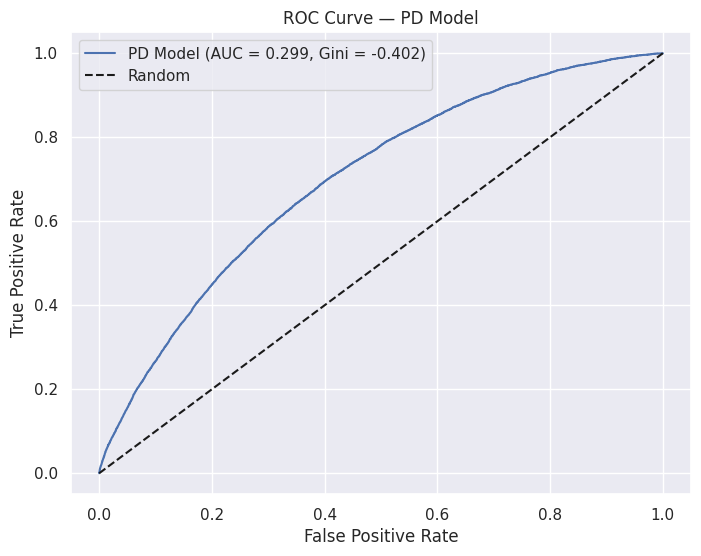

In [65]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(actual, y_hat_test_proba_default, pos_label=0)

AUROC = roc_auc_score(actual, y_hat_test_proba_default)
Gini  = 2 * AUROC - 1
KS    = max(tpr - fpr)

print(f"AUROC : {AUROC:.4f}")
print(f"Gini  : {Gini:.4f}")
print(f"KS    : {KS:.4f}")

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'PD Model (AUC = {AUROC:.3f}, Gini = {Gini:.3f})')
plt.plot([0,1],[0,1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — PD Model')
plt.legend()
plt.show()


## 2.4 Build a Credit Scorecard

A **scorecard** converts model probabilities into integer scores (like a credit score).
Lenders set a **cut-off score** - applicants below the cut-off are rejected.

The formula to convert a probability to a score is:

`Score = Offset + Factor × log(Odds)`

Where:
- **Odds** = probability of being good / probability of being bad
- We set: Score of 600 = Odds of 1:1 (50% chance of being good), with 20 points per doubling of odds (PDO=20)


In [66]:
# Scorecard parameters (industry standard settings)
min_score = 300
max_score = 850

# We calculate the score for each feature using its coefficient
summary_table['Original feature name'] = summary_table['Feature name'].str.split(':').str[0]

# Min / Max coefficients per variable
df_ref_categories = pd.DataFrame(ref_categories, columns=['Feature name'])
df_ref_categories['Coefficients'] = 0
df_ref_categories['p_values'] = np.nan
df_ref_categories['Original feature name'] = df_ref_categories['Feature name'].str.split(':').str[0]

df_scorecard = pd.concat([summary_table, df_ref_categories])
df_scorecard = df_scorecard.reset_index(drop=True)

# Score calculation
min_sum_coef = df_scorecard.groupby('Original feature name')['Coefficients'].min().sum()
max_sum_coef = df_scorecard.groupby('Original feature name')['Coefficients'].max().sum()

df_scorecard['Score - Calculation'] = df_scorecard['Coefficients'] *     (max_score - min_score) / (max_sum_coef - min_sum_coef)

# Adjust scores so they sum to the right range
df_scorecard['Score - Calculation'][df_scorecard['Feature name'] == 'Intercept'] =     ((reg.intercept_[0] - min_sum_coef) / (max_sum_coef - min_sum_coef)) *     (max_score - min_score) + min_score

df_scorecard['Score - Final'] = df_scorecard['Score - Calculation'].round()

print("Scorecard (top 20 entries):")
df_scorecard[['Feature name','Coefficients','Score - Final']].head(20)


Scorecard (top 20 entries):


,Feature name,Coefficients,Score - Final
0,Intercept,-0.258438,353.0
1,grade:A,0.988321,81.0
2,grade:B,0.782561,64.0
3,grade:C,0.590804,48.0
4,grade:D,0.408448,33.0
5,grade:E,0.248021,20.0
6,grade:F,0.060338,5.0
7,home_ownership:OWN,0.082678,7.0
8,home_ownership:MORTGAGE,0.116555,10.0
9,addr_state:NM_VA,0.046792,4.0


Credit Score Distribution:
count     93257.0
unique      389.0
top         562.0
freq        621.0
dtype: float64


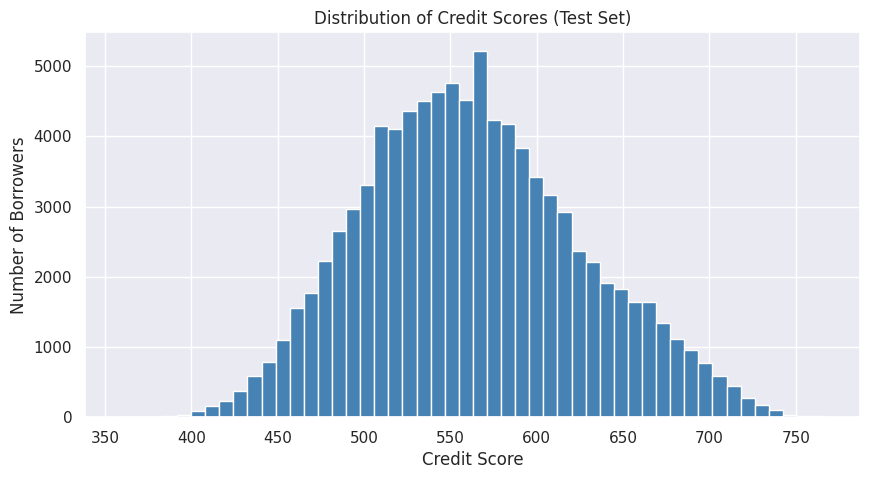

In [67]:
# Calculate the credit score for each loan in test set
# For each borrower, we sum the scores of the bins they fall into

# Prepare test features with reference categories included
inputs_test_with_ref_cat_for_score = inputs_test_with_ref_cat.copy()
inputs_test_with_ref_cat_for_score[ref_categories] = 0  # add reference category columns as 0

scorecard_scores = df_scorecard.set_index('Feature name')['Score - Final']
# Only keep features that appear in both
common_features = [f for f in scorecard_scores.index if f in inputs_test_with_ref_cat_for_score.columns and f != 'Intercept']
intercept_score = float(scorecard_scores.get('Intercept', 0))

scores = inputs_test_with_ref_cat_for_score[common_features].dot(scorecard_scores[common_features]) + intercept_score

print("Credit Score Distribution:")
print(scores.describe().round(1))

plt.figure(figsize=(10,5))
plt.hist(scores, bins=50, color='steelblue', edgecolor='white')
plt.xlabel('Credit Score')
plt.ylabel('Number of Borrowers')
plt.title('Distribution of Credit Scores (Test Set)')
plt.show()


In [68]:
# Save PD model
pickle.dump(reg, open('pd_model.sav', 'wb'))
print("PD model saved as 'pd_model.sav'")


PD model saved as 'pd_model.sav'


---
# Section 3: Loss Given Default (LGD) Model

**Loss Given Default (LGD)** = how much of the loan we lose if the borrower defaults.

`LGD = 1 − Recovery Rate`

We are using a **two-stage approach**:
- **Stage 1 (Logistic Regression):** Did we recover anything at all? (0 or >0)
- **Stage 2 (Linear Regression):** If we did recover something, how much?

Final LGD = `1 − (Stage1_prediction × Stage2_prediction)`


In [69]:
# We work only with defaulted loans for LGD and EAD
loan_data_defaults = loan_data[loan_data['loan_status'].isin([
    'Charged Off', 'Does not meet the credit policy. Status:Charged Off'
])]

# Fill missing values
loan_data_defaults = loan_data_defaults.copy()
loan_data_defaults['mths_since_last_delinq'].fillna(0, inplace=True)
loan_data_defaults['mths_since_last_record'].fillna(0, inplace=True)

print(f"Defaulted loans: {loan_data_defaults.shape[0]:,}")


Defaulted loans: 43,236


In [70]:
# Calculate Recovery Rate (target for LGD)
loan_data_defaults['recovery_rate'] = loan_data_defaults['recoveries'] / loan_data_defaults['funded_amnt']
loan_data_defaults['recovery_rate'] = np.where(loan_data_defaults['recovery_rate'] > 1, 1, loan_data_defaults['recovery_rate'])
loan_data_defaults['recovery_rate'] = np.where(loan_data_defaults['recovery_rate'] < 0, 0, loan_data_defaults['recovery_rate'])

# Calculate CCF (Credit Conversion Factor) — target for EAD
loan_data_defaults['CCF'] = (loan_data_defaults['funded_amnt'] - loan_data_defaults['total_rec_prncp']) /                              loan_data_defaults['funded_amnt']

# Stage 1 binary target: did any recovery happen at all?
loan_data_defaults['recovery_rate_0_1'] = np.where(loan_data_defaults['recovery_rate'] == 0, 0, 1)

print("Recovery Rate stats:")
print(loan_data_defaults['recovery_rate'].describe().round(3))
print(f"\nLoans with some recovery: {loan_data_defaults['recovery_rate_0_1'].mean():.2%}")


Recovery Rate stats:
count    43236.000
mean         0.061
std          0.089
min          0.000
25%          0.000
50%          0.029
75%          0.114
max          1.000
Name: recovery_rate, dtype: float64

Loans with some recovery: 56.37%


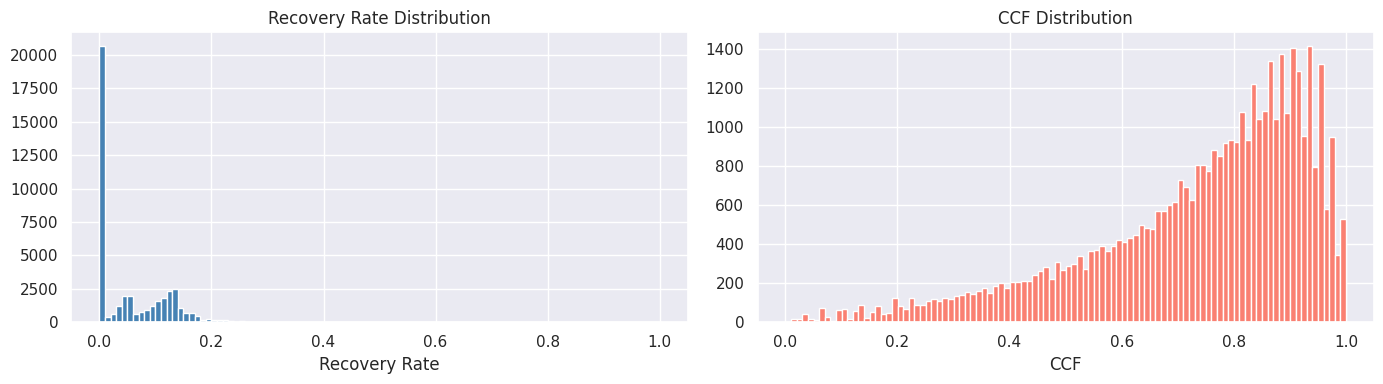

In [71]:
# Visualise recovery rate and CCF distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(loan_data_defaults['recovery_rate'], bins=100, color='steelblue')
axes[0].set_title('Recovery Rate Distribution'); axes[0].set_xlabel('Recovery Rate')
axes[1].hist(loan_data_defaults['CCF'], bins=100, color='salmon')
axes[1].set_title('CCF Distribution'); axes[1].set_xlabel('CCF')
plt.tight_layout(); plt.show()


In [72]:
# LGD features - same WoE-encoded variables
features_lgd_ead = ['grade:A','grade:B','grade:C','grade:D','grade:E','grade:F','grade:G',
    'home_ownership:MORTGAGE','home_ownership:NONE','home_ownership:OTHER',
    'home_ownership:OWN','home_ownership:RENT',
    'verification_status:Not Verified','verification_status:Source Verified','verification_status:Verified',
    'purpose:car','purpose:credit_card','purpose:debt_consolidation','purpose:educational',
    'purpose:home_improvement','purpose:house','purpose:major_purchase','purpose:medical',
    'purpose:moving','purpose:other','purpose:renewable_energy','purpose:small_business',
    'purpose:vacation','purpose:wedding',
    'initial_list_status:f','initial_list_status:w',
    'term_int','emp_length_int','mths_since_issue_d','mths_since_earliest_cr_line',
    'funded_amnt','int_rate','installment','annual_inc','dti',
    'delinq_2yrs','inq_last_6mths','open_acc','pub_rec','revol_bal','revol_util','total_acc',
    'out_prncp','out_prncp_inv','total_pymnt','total_pymnt_inv','total_rec_prncp',
    'total_rec_int','total_rec_late_fee','recoveries','collection_recovery_fee',
    'last_pymnt_amnt','mths_since_last_delinq','mths_since_last_record','acc_now_delinq']

# Keep only columns that exist
features_lgd_ead = [f for f in features_lgd_ead if f in loan_data_defaults.columns]

# Train/test split for LGD
lgd_inputs_stage_1_train, lgd_inputs_stage_1_test, lgd_targets_stage_1_train, lgd_targets_stage_1_test = train_test_split(
    loan_data_defaults[features_lgd_ead],
    loan_data_defaults['recovery_rate_0_1'],
    test_size=0.2, random_state=42
)
print(f"LGD train: {lgd_inputs_stage_1_train.shape[0]:,}  |  LGD test: {lgd_inputs_stage_1_test.shape[0]:,}")


LGD train: 34,588  |  LGD test: 8,648


## 3.1 LGD Stage 1 - Logistic Regression (Did any recovery occur?)

In [75]:
lgd_inputs_stage_1_train.fillna(0, inplace=True)
lgd_inputs_stage_1_test.fillna(0, inplace=True)

# Remove columns with zero variance to prevent LinAlgError: Singular matrix
zero_variance_cols = lgd_inputs_stage_1_train.columns[lgd_inputs_stage_1_train.std() == 0]
if not zero_variance_cols.empty:
    print(f"Dropping zero-variance columns: {list(zero_variance_cols)}")
    lgd_inputs_stage_1_train = lgd_inputs_stage_1_train.drop(columns=zero_variance_cols)
    lgd_inputs_stage_1_test = lgd_inputs_stage_1_test.drop(columns=zero_variance_cols)

reg_lgd_st_1 = LogisticRegression_with_p_values()
reg_lgd_st_1.fit(lgd_inputs_stage_1_train, lgd_targets_stage_1_train)

feature_name = lgd_inputs_stage_1_train.columns.values
summary_lgd_1 = pd.DataFrame(columns=['Feature name'], data=feature_name)
summary_lgd_1['Coefficients'] = np.transpose(reg_lgd_st_1.coef_)
summary_lgd_1.index = summary_lgd_1.index + 1
summary_lgd_1.loc[0] = ['Intercept', reg_lgd_st_1.intercept_[0]]
summary_lgd_1 = summary_lgd_1.sort_index()
p_values = np.append(np.nan, np.array(reg_lgd_st_1.p_values))
summary_lgd_1['p_values'] = p_values.round(3)
summary_lgd_1

Dropping zero-variance columns: ['out_prncp', 'out_prncp_inv']


,Feature name,Coefficients,p_values
0,Intercept,-4.739209e-05,NaN
1,grade:A,1.106638e-05,NaN
2,grade:B,-7.718514e-06,NaN
3,grade:C,-3.001940e-05,NaN
4,grade:D,-1.667899e-05,NaN
5,grade:E,-9.093047e-06,NaN
6,grade:F,4.081473e-06,NaN
7,grade:G,9.700045e-07,NaN
8,home_ownership:MORTGAGE,-1.067119e-05,NaN
9,home_ownership:NONE,9.368615e-08,NaN


In [76]:
# Evaluate LGD Stage 1
y_hat_test_proba_lgd_st1 = reg_lgd_st_1.model.predict_proba(lgd_inputs_stage_1_test)[:, 1]
AUROC_lgd_st1 = roc_auc_score(lgd_targets_stage_1_test, y_hat_test_proba_lgd_st1)
print(f"LGD Stage 1 AUROC: {AUROC_lgd_st1:.4f}")

# Confusion matrix at threshold 0.5
tr = 0.5
y_hat_test_lgd_st1 = np.where(y_hat_test_proba_lgd_st1 > tr, 1, 0)
print("\nConfusion Matrix:")
print(pd.crosstab(lgd_targets_stage_1_test, y_hat_test_lgd_st1,
                  rownames=['Actual'], colnames=['Predicted']))


LGD Stage 1 AUROC: 0.9987

Confusion Matrix:
Predicted     0     1
Actual               
0          3722    40
1            45  4841


## 3.2 LGD Stage 2 - Linear Regression (How much was recovered?)

In [80]:
from sklearn import linear_model

class LinearRegression(linear_model.LinearRegression):
    """LinearRegression extended with p-values for coefficients."""
    def fit(self, X, y, n_jobs=1):
        self = super(LinearRegression, self).fit(X, y)
        # Explicitly cast X to float64 to prevent UFuncTypeError with np.linalg.inv
        X = np.asarray(X, dtype=np.float64)
        sse = np.sum((self.predict(X) - y) ** 2, axis=0) / float(X.shape[0] - X.shape[1])
        se = np.array([np.sqrt(np.diagonal(sse * np.linalg.inv(np.dot(X.T, X))))])
        self.t = self.coef_ / se
        self.p = np.squeeze(2 * (1 - stat.t.cdf(np.abs(self.t), y.shape[0] - X.shape[1])))
        return self

# Stage 2: only loans where recovery > 0
lgd_stage_2_data = loan_data_defaults[loan_data_defaults['recovery_rate_0_1'] == 1]

lgd_inputs_stage_2_train, lgd_inputs_stage_2_test, lgd_targets_stage_2_train, lgd_targets_stage_2_test = train_test_split(
    lgd_stage_2_data[features_lgd_ead],
    lgd_stage_2_data['recovery_rate'],
    test_size=0.2, random_state=42
)

# Fill NaN values in the input data for Stage 2
lgd_inputs_stage_2_train.fillna(0, inplace=True)
lgd_inputs_stage_2_test.fillna(0, inplace=True)

# Remove columns with zero variance to prevent LinAlgError: Singular matrix
zero_variance_cols_st2 = lgd_inputs_stage_2_train.columns[lgd_inputs_stage_2_train.std() == 0]
if not zero_variance_cols_st2.empty:
    print(f"Dropping zero-variance columns from LGD Stage 2: {list(zero_variance_cols_st2)}")
    lgd_inputs_stage_2_train = lgd_inputs_stage_2_train.drop(columns=zero_variance_cols_st2)
    lgd_inputs_stage_2_test = lgd_inputs_stage_2_test.drop(columns=zero_variance_cols_st2)

reg_lgd_st_2 = LinearRegression()
reg_lgd_st_2.fit(lgd_inputs_stage_2_train, lgd_targets_stage_2_train)

feature_name = lgd_inputs_stage_2_train.columns.values
summary_lgd_2 = pd.DataFrame(columns=['Feature name'], data=feature_name)
summary_lgd_2['Coefficients'] = np.transpose(reg_lgd_st_2.coef_)
summary_lgd_2.index = summary_lgd_2.index + 1
summary_lgd_2.loc[0] = ['Intercept', reg_lgd_st_2.intercept_]
summary_lgd_2 = summary_lgd_2.sort_index()
p_values = np.append(np.nan, np.array(reg_lgd_st_2.p))
summary_lgd_2['p_values'] = p_values.round(3)
summary_lgd_2

Dropping zero-variance columns from LGD Stage 2: ['out_prncp', 'out_prncp_inv']


,Feature name,Coefficients,p_values
0,Intercept,1.742670e-01,NaN
1,grade:A,-9.560991e-03,1.000
2,grade:B,-3.708239e-03,1.000
3,grade:C,3.313772e-04,1.000
4,grade:D,2.062052e-03,1.000
5,grade:E,4.113271e-03,1.000
6,grade:F,3.872570e-03,1.000
7,grade:G,2.889959e-03,1.000
8,home_ownership:MORTGAGE,-1.760803e-02,NaN
9,home_ownership:NONE,7.528057e-02,NaN


LGD Stage 2 — Correlation between actual and predicted: 0.8280


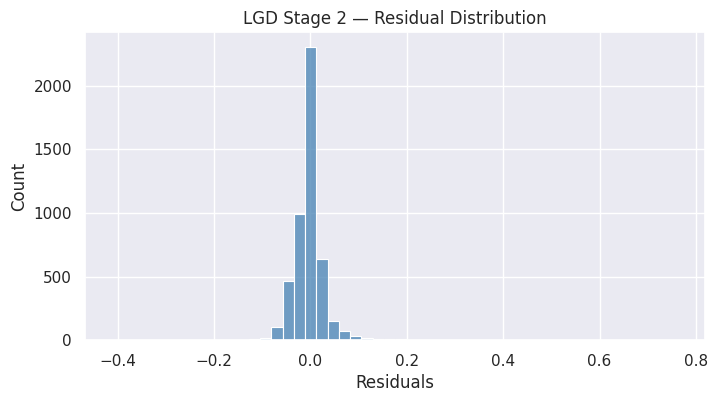

In [81]:
# Evaluate Stage 2
y_hat_test_lgd_st2 = reg_lgd_st_2.predict(lgd_inputs_stage_2_test)
corr_lgd_st2 = np.corrcoef(lgd_targets_stage_2_test, y_hat_test_lgd_st2)[0, 1]
print(f"LGD Stage 2 — Correlation between actual and predicted: {corr_lgd_st2:.4f}")

# Residuals plot
plt.figure(figsize=(8, 4))
sns.histplot(lgd_targets_stage_2_test.values - y_hat_test_lgd_st2, bins=50, color='steelblue')
plt.xlabel('Residuals'); plt.title('LGD Stage 2 — Residual Distribution')
plt.show()


## 3.3 Combine Stage 1 and Stage 2 - Final LGD

In [82]:
# Stage 1: probability of any recovery
y_hat_lgd_st1_all = reg_lgd_st_1.model.predict(lgd_inputs_stage_1_test)
# Stage 2: how much recovery (applied to ALL test loans, not just those with recovery)
y_hat_lgd_st2_all = reg_lgd_st_2.predict(lgd_inputs_stage_1_test)

# Combined: final LGD = 1 - (stage1 * stage2)
y_hat_lgd = y_hat_lgd_st1_all * y_hat_lgd_st2_all
y_hat_lgd = np.where(y_hat_lgd < 0, 0, y_hat_lgd)
y_hat_lgd = np.where(y_hat_lgd > 1, 1, y_hat_lgd)

print("Final LGD prediction stats:")
print(pd.DataFrame(y_hat_lgd, columns=['LGD']).describe().round(4))

# Save models
pickle.dump(reg_lgd_st_1, open('lgd_model_stage_1.sav', 'wb'))
pickle.dump(reg_lgd_st_2, open('lgd_model_stage_2.sav', 'wb'))
print("\nLGD models saved.")


Final LGD prediction stats:
             LGD
count  8648.0000
mean      0.0619
std       0.0788
min       0.0000
25%       0.0000
50%       0.0427
75%       0.1123
max       1.0000

LGD models saved.


---
# Section 4: Exposure at Default (EAD) Model

`EAD = CCF × Funded Amount`

The **Credit Conversion Factor (CCF)** is the fraction of the loan still outstanding at default.
We model it using Linear Regression on the defaulted loan population.


In [84]:
ead_inputs_train, ead_inputs_test, ead_targets_train, ead_targets_test = train_test_split(
    loan_data_defaults[features_lgd_ead],
    loan_data_defaults['CCF'],
    test_size=0.2, random_state=42
)

# Fill NaN values in the input data for EAD
ead_inputs_train.fillna(0, inplace=True)
ead_inputs_test.fillna(0, inplace=True)

# Remove columns with zero variance to prevent LinAlgError: Singular matrix
zero_variance_cols_ead = ead_inputs_train.columns[ead_inputs_train.std() == 0]
if not zero_variance_cols_ead.empty:
    print(f"Dropping zero-variance columns from EAD: {list(zero_variance_cols_ead)}")
    ead_inputs_train = ead_inputs_train.drop(columns=zero_variance_cols_ead)
    ead_inputs_test = ead_inputs_test.drop(columns=zero_variance_cols_ead)

reg_ead = LinearRegression()
reg_ead.fit(ead_inputs_train, ead_targets_train)

feature_name = ead_inputs_train.columns.values
summary_ead = pd.DataFrame(columns=['Feature name'], data=feature_name)
summary_ead['Coefficients'] = np.transpose(reg_ead.coef_)
summary_ead.index = summary_ead.index + 1
summary_ead.loc[0] = ['Intercept', reg_ead.intercept_]
summary_ead = summary_ead.sort_index()
p_values = np.append(np.nan, np.array(reg_ead.p))
summary_ead['p_values'] = p_values.round(3)
summary_ead

Dropping zero-variance columns from EAD: ['out_prncp', 'out_prncp_inv']


,Feature name,Coefficients,p_values
0,Intercept,8.168816e-01,NaN
1,grade:A,-6.757991e-02,1.000
2,grade:B,-2.932067e-02,1.000
3,grade:C,-1.065105e-03,1.000
4,grade:D,1.428138e-02,1.000
5,grade:E,2.862293e-02,1.000
6,grade:F,3.440292e-02,1.000
7,grade:G,2.065846e-02,1.000
8,home_ownership:MORTGAGE,5.345530e-03,NaN
9,home_ownership:NONE,-1.217476e-02,NaN


In [85]:
# Evaluate EAD
y_hat_test_ead = reg_ead.predict(ead_inputs_test)
corr_ead = np.corrcoef(ead_targets_test.reset_index(drop=True), y_hat_test_ead)[0, 1]
print(f"EAD Model — Correlation between actual and predicted CCF: {corr_ead:.4f}")

# Distribution of predicted CCF
y_hat_test_ead = np.where(y_hat_test_ead < 0, 0, y_hat_test_ead)
y_hat_test_ead = np.where(y_hat_test_ead > 1, 1, y_hat_test_ead)
print("\nPredicted CCF stats:")
print(pd.DataFrame(y_hat_test_ead, columns=['CCF']).describe().round(4))

# Save EAD model
pickle.dump(reg_ead, open('ead_model.sav', 'wb'))
print("\nEAD model saved.")


EAD Model — Correlation between actual and predicted CCF: 0.8687

Predicted CCF stats:
             CCF
count  8648.0000
mean      0.7334
std       0.1656
min       0.0000
25%       0.6529
50%       0.7501
75%       0.8457
max       1.0000

EAD model saved.


---
# Section 5: Expected Loss

## EL = PD \times LGD \times EAD

We now apply all three models to the entire preprocessed dataset and calculate Expected Loss per loan.


In [88]:
import warnings
warnings.filterwarnings('ignore')

# Prepare the full dataset for scoring
loan_data_preprocessed = loan_data.copy()
loan_data_preprocessed['mths_since_last_delinq'].fillna(0, inplace=True)
loan_data_preprocessed['mths_since_last_record'].fillna(0, inplace=True)
loan_data_preprocessed['revol_util'].fillna(0, inplace=True)

# Features for LGD/EAD scoring
loan_data_preprocessed_lgd_ead = loan_data_preprocessed[features_lgd_ead]

# Drop zero-variance columns from the scoring dataset, matching the training data
# zero_variance_cols was identified during LGD Stage 1 training
if not zero_variance_cols.empty:
    loan_data_preprocessed_lgd_ead = loan_data_preprocessed_lgd_ead.drop(columns=zero_variance_cols, errors='ignore')

# Score LGD
loan_data_preprocessed['recovery_rate_st_1'] = reg_lgd_st_1.model.predict(loan_data_preprocessed_lgd_ead)
loan_data_preprocessed['recovery_rate_st_2'] = reg_lgd_st_2.predict(loan_data_preprocessed_lgd_ead)
loan_data_preprocessed['recovery_rate'] = loan_data_preprocessed['recovery_rate_st_1'] *                                            loan_data_preprocessed['recovery_rate_st_2']
loan_data_preprocessed['recovery_rate'] = loan_data_preprocessed['recovery_rate'].clip(0, 1)
loan_data_preprocessed['LGD'] = 1 - loan_data_preprocessed['recovery_rate']

print("LGD stats:"); print(loan_data_preprocessed['LGD'].describe().round(4))

LGD stats:
count    466285.0000
mean          0.9942
std           0.0299
min           0.0000
25%           1.0000
50%           1.0000
75%           1.0000
max           1.0000
Name: LGD, dtype: float64


In [89]:
# Score EAD
loan_data_preprocessed['CCF'] = reg_ead.predict(loan_data_preprocessed_lgd_ead).clip(0, 1)
loan_data_preprocessed['EAD'] = loan_data_preprocessed['CCF'] * loan_data_preprocessed_lgd_ead['funded_amnt']
print("EAD stats:"); print(loan_data_preprocessed['EAD'].describe().round(2))


EAD stats:
count    466285.00
mean       6329.72
std        6065.24
min           0.00
25%        2589.33
50%        3940.24
75%        8740.97
max       35000.00
Name: EAD, dtype: float64


In [90]:
# Score PD
# Prepare PD features for full dataset
loan_data_inputs_pd = loan_data_preprocessed.copy()

# Re-apply all the same WoE bins to full dataset
loan_data_inputs_pd['home_ownership:RENT_OTHER_NONE_ANY'] = sum([
    loan_data_inputs_pd.get('home_ownership:RENT', 0), loan_data_inputs_pd.get('home_ownership:OTHER', 0),
    loan_data_inputs_pd.get('home_ownership:NONE', 0), loan_data_inputs_pd.get('home_ownership:ANY', 0)
])
if 'addr_state:ND' not in loan_data_inputs_pd.columns:
    loan_data_inputs_pd['addr_state:ND'] = 0

for col, states in [
    ('addr_state:ND_NE_IA_NV_FL_HI_AL', ['addr_state:ND','addr_state:NE','addr_state:IA','addr_state:NV','addr_state:FL','addr_state:HI','addr_state:AL']),
    ('addr_state:NM_VA', ['addr_state:NM','addr_state:VA']),
    ('addr_state:OK_TN_MO_LA_MD_NC', ['addr_state:OK','addr_state:TN','addr_state:MO','addr_state:LA','addr_state:MD','addr_state:NC']),
    ('addr_state:UT_KY_AZ_NJ', ['addr_state:UT','addr_state:KY','addr_state:AZ','addr_state:NJ']),
    ('addr_state:AR_MI_PA_OH_MN', ['addr_state:AR','addr_state:MI','addr_state:PA','addr_state:OH','addr_state:MN']),
    ('addr_state:RI_MA_DE_SD_IN', ['addr_state:RI','addr_state:MA','addr_state:DE','addr_state:SD','addr_state:IN']),
    ('addr_state:GA_WA_OR', ['addr_state:GA','addr_state:WA','addr_state:OR']),
    ('addr_state:WI_MT', ['addr_state:WI','addr_state:MT']),
    ('addr_state:IL_CT', ['addr_state:IL','addr_state:CT']),
    ('addr_state:KS_SC_CO_VT_AK_MS', ['addr_state:KS','addr_state:SC','addr_state:CO','addr_state:VT','addr_state:AK','addr_state:MS']),
    ('addr_state:WV_NH_WY_DC_ME_ID', ['addr_state:WV','addr_state:NH','addr_state:WY','addr_state:DC','addr_state:ME','addr_state:ID']),
]:
    loan_data_inputs_pd[col] = sum([loan_data_inputs_pd.get(s, pd.Series(0, index=loan_data_inputs_pd.index)) for s in states])

loan_data_inputs_pd['purpose:educ__sm_b__wedd__ren_en__mov__house'] = sum([
    loan_data_inputs_pd.get('purpose:educational',0), loan_data_inputs_pd.get('purpose:small_business',0),
    loan_data_inputs_pd.get('purpose:wedding',0),     loan_data_inputs_pd.get('purpose:renewable_energy',0),
    loan_data_inputs_pd.get('purpose:moving',0),      loan_data_inputs_pd.get('purpose:house',0)
])
loan_data_inputs_pd['purpose:oth__med__vacation'] = sum([
    loan_data_inputs_pd.get('purpose:other',0), loan_data_inputs_pd.get('purpose:medical',0),
    loan_data_inputs_pd.get('purpose:vacation',0)
])
loan_data_inputs_pd['purpose:major_purch__car__home_impr'] = sum([
    loan_data_inputs_pd.get('purpose:major_purchase',0), loan_data_inputs_pd.get('purpose:car',0),
    loan_data_inputs_pd.get('purpose:home_improvement',0)
])

# Apply continuous bins
for col_out, col_in, lo, hi in [
    ('term:36','term_int',36,36), ('term:60','term_int',60,60),
    ('emp_length:0','emp_length_int',0,0), ('emp_length:1','emp_length_int',1,1),
    ('emp_length:2-4','emp_length_int',2,4), ('emp_length:5-6','emp_length_int',5,6),
    ('emp_length:7-9','emp_length_int',7,9), ('emp_length:10','emp_length_int',10,10),
]:
    loan_data_inputs_pd[col_out] = np.where(loan_data_inputs_pd[col_in].between(lo,hi), 1, 0)

bins_dict = {
    'mths_since_issue_d': [('<38',None,38),('38-39',38,39),('40-41',40,41),('42-48',42,48),
                            ('49-52',49,52),('53-64',53,64),('65-84',65,84),('>84',84,None)],
    'int_rate': [('<9.548',None,9.548),('9.548-12.025',9.548,12.025),('12.025-15.74',12.025,15.74),
                 ('15.74-20.281',15.74,20.281),('>20.281',20.281,None)],
    'mths_since_earliest_cr_line': [('<140',None,140),('141-164',141,164),('165-247',165,247),('>247',247,None)],
    'delinq_2yrs': [('0',0,0),('1-3',1,3),('>=4',4,None)],
    'inq_last_6mths': [('0',0,0),('1-2',1,2),('3-6',3,6),('>6',6,None)],
    'open_acc': [('0',0,0),('1-3',1,3),('4-12',4,12),('13-17',13,17),('18-22',18,22),('23-25',23,25),('26-30',26,30),('>=31',31,None)],
    'pub_rec': [('0-2',0,2),('3-4',3,4),('>=5',5,None)],
    'total_acc': [('<=27',None,27),('28-51',28,51),('>=52',52,None)],
    'acc_now_delinq': [('0',0,0),('>=1',1,None)],
    'total_rev_hi_lim': [('<=5K',None,5000),('5K-10K',5000,10000),('10K-20K',10000,20000),('20K-30K',20000,30000),
                          ('30K-40K',30000,40000),('40K-55K',40000,55000),('55K-95K',55000,95000),('>95K',95000,None)],
    'annual_inc': [('<20K',None,20000),('20K-30K',20000,30000),('30K-40K',30000,40000),('40K-50K',40000,50000),
                   ('50K-60K',50000,60000),('60K-70K',60000,70000),('70K-80K',70000,80000),('80K-90K',80000,90000),
                   ('90K-100K',90000,100000),('100K-120K',100000,120000),('120K-140K',120000,140000),('>140K',140000,None)],
    'dti': [('<=1.4',None,1.4),('1.4-3.5',1.4,3.5),('3.5-7.7',3.5,7.7),('7.7-10.5',7.7,10.5),
            ('10.5-16.1',10.5,16.1),('16.1-20.3',16.1,20.3),('20.3-21.7',20.3,21.7),('21.7-22.4',21.7,22.4),
            ('22.4-35',22.4,35),('>35',35,None)],
    'mths_since_last_delinq': [('0-3',0,3),('4-30',4,30),('31-56',31,56),('>=57',57,None)],
    'mths_since_last_record': [('0-2',0,2),('3-20',3,20),('21-31',21,31),('32-80',32,80),('81-86',81,86),('>=87',87,None)],
}
for orig_col, bins in bins_dict.items():
    for label, lo, hi in bins:
        new_col = f"{orig_col}:{label}"
        if lo is None:
            loan_data_inputs_pd[new_col] = np.where(loan_data_inputs_pd[orig_col] <= hi, 1, 0)
        elif hi is None:
            loan_data_inputs_pd[new_col] = np.where(loan_data_inputs_pd[orig_col] >= lo, 1, 0)
        else:
            loan_data_inputs_pd[new_col] = np.where(loan_data_inputs_pd[orig_col].between(lo, hi), 1, 0)

loan_data_inputs_pd_temp = loan_data_inputs_pd[features_all].drop(ref_categories, axis=1)
loan_data_preprocessed['PD'] = reg.model.predict_proba(loan_data_inputs_pd_temp)[:, 0]
print("PD scores calculated.")
print(loan_data_preprocessed['PD'].describe().round(4))


PD scores calculated.
count    466285.0000
mean          0.1054
std           0.0725
min           0.0028
25%           0.0496
50%           0.0898
75%           0.1450
max           0.5558
Name: PD, dtype: float64


In [91]:
# Calculate Expected Loss
loan_data_preprocessed['EL'] = (loan_data_preprocessed['PD'] *
                                  loan_data_preprocessed['LGD'] *
                                  loan_data_preprocessed['EAD'])

print("=" * 50)
print("EXPECTED LOSS — PORTFOLIO SUMMARY")
print("=" * 50)
print(f"Total Funded Amount  : ${loan_data_preprocessed['funded_amnt'].sum():>15,.0f}")
print(f"Total Expected Loss  : ${loan_data_preprocessed['EL'].sum():>15,.0f}")
print(f"EL as % of Portfolio : {loan_data_preprocessed['EL'].sum() / loan_data_preprocessed['funded_amnt'].sum():.2%}")
print()
print("Per-loan EL stats:")
print(loan_data_preprocessed[['PD','LGD','EAD','EL']].describe().round(4))


EXPECTED LOSS — PORTFOLIO SUMMARY
Total Funded Amount  : $  6,664,052,450
Total Expected Loss  : $    298,784,673
EL as % of Portfolio : 4.48%

Per-loan EL stats:
                PD          LGD          EAD           EL
count  466285.0000  466285.0000  466285.0000  466285.0000
mean        0.1054       0.9942    6329.7201     640.7769
std         0.0725       0.0299    6065.2429     889.3638
min         0.0028       0.0000       0.0000       0.0000
25%         0.0496       1.0000    2589.3333     150.9502
50%         0.0898       1.0000    3940.2361     341.4015
75%         0.1450       1.0000    8740.9737     727.9915
max         0.5558       1.0000   35000.0000   15369.7232


In [92]:
loan_data_preprocessed[['funded_amnt','PD','LGD','EAD','EL']].head(10)


,funded_amnt,PD,LGD,EAD,EL
0,5000,0.145972,1.000000,2495.885627,364.329402
1,2500,0.298509,0.912358,1925.514624,524.408135
2,2400,0.176301,1.000000,1437.597459,253.449447
3,10000,0.194638,1.000000,3048.505450,593.355532
4,3000,0.127482,1.000000,2061.444847,262.797057
5,5000,0.123844,1.000000,2455.376585,304.083660
6,7000,0.288076,1.000000,3921.350620,1129.647903
7,3000,0.293202,1.000000,1638.674687,480.463140
8,5600,0.433655,0.918667,4610.474188,1836.742055
9,5375,0.144099,0.912011,4342.770808,570.728035


---
# Section 6: Model Monitoring - Population Stability Index (PSI)

**Population Stability Index (PSI)** measures whether the borrower population has changed since the model was built.

| PSI Value | Meaning |
|---|---|
| < 0.10 | Population stable - model still valid |
| 0.10 – 0.25 | Minor shift - monitor closely |
| > 0.25 | Major shift - model needs rebuilding |

We compare the **2007–2014 training data** (when we built the model) with **new 2015 data** (after deployment).


In [93]:
# Load new 2015 data
loan_data_2015_backup = pd.read_csv('loan_data_2015.csv')
loan_data_2015 = loan_data_2015_backup.copy()
print(f"2015 data shape: {loan_data_2015.shape}")
loan_data_2015.head()


2015 data shape: (421094, 74)


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,68444620,73334399,35000,35000,35000.0,60 months,11.99,778.38,C,C1,Foreign Service Officer,10+ years,MORTGAGE,128000.0,Source Verified,Dec-15,Issued,n,https://www.lendingclub.com/browse/loanDetail....,NaN,home_improvement,Home improvement,200xx,DC,6.46,0.0,Feb-90,0.0,46.0,NaN,17.0,0.0,14277,27.4,46.0,w,35000.0,35000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,Jan-16,Jan-16,0.0,56.0,1,INDIVIDUAL,NaN,NaN,NaN,0.0,321.0,146867.0,1.0,11.0,0.0,0.0,28.0,35367.0,49.3,0.0,1.0,5020.0,40.1,52200.0,1.0,4.0,0.0
1,68547583,73437441,8650,8650,8650.0,36 months,5.32,260.50,A,A1,Associate Consultant,< 1 year,MORTGAGE,100000.0,Not Verified,Dec-15,Issued,n,https://www.lendingclub.com/browse/loanDetail....,NaN,credit_card,Credit card refinancing,462xx,IN,7.28,0.0,Jul-01,0.0,NaN,NaN,15.0,0.0,7158,26.7,24.0,w,8650.0,8650.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,Jan-16,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,0.0,165450.0,0.0,1.0,1.0,1.0,11.0,24041.0,88.8,0.0,3.0,3081.0,57.9,26800.0,1.0,0.0,5.0
2,67849662,72708407,4225,4225,4225.0,36 months,14.85,146.16,C,C5,mechanic,5 years,RENT,35000.0,Source Verified,Dec-15,Issued,n,https://www.lendingclub.com/browse/loanDetail....,NaN,debt_consolidation,Debt consolidation,672xx,KS,15.22,2.0,Jul-11,0.0,18.0,NaN,6.0,0.0,1058,24.6,6.0,w,4225.0,4225.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,Jan-16,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,0.0,4888.0,0.0,1.0,0.0,0.0,47.0,3830.0,21.9,0.0,0.0,367.0,22.4,4300.0,0.0,0.0,0.0
3,68506885,73396712,10000,10000,10000.0,60 months,11.99,222.40,C,C1,CARDIOVASCULAR TECH,10+ years,RENT,42500.0,Not Verified,Dec-15,Issued,n,https://www.lendingclub.com/browse/loanDetail....,NaN,debt_consolidation,Debt consolidation,460xx,IN,31.04,0.0,Dec-98,1.0,NaN,NaN,10.0,0.0,5812,40.9,23.0,w,10000.0,10000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,Jan-16,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,0.0,41166.0,1.0,3.0,0.0,2.0,13.0,35354.0,75.5,1.0,1.0,3118.0,67.4,14200.0,1.0,1.0,1.0
4,68341763,72928789,20000,20000,20000.0,60 months,10.78,432.66,B,B4,truck driver,10+ years,MORTGAGE,63000.0,Not Verified,Dec-15,Issued,n,https://www.lendingclub.com/browse/loanDetail....,NaN,home_improvement,NaN,605xx,IL,10.78,0.0,Aug-00,0.0,NaN,NaN,6.0,0.0,7869,56.2,18.0,w,20000.0,20000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,Jan-16,Dec-15,0.0,NaN,1,JOINT,71000.0,13.85,Not Verified,0.0,0.0,189699.0,0.0,1.0,0.0,4.0,19.0,10827.0,72.8,0.0,2.0,2081.0,64.7,14000.0,2.0,5.0,1.0


In [97]:
loan_data_2015['emp_length_int'] = pd.to_numeric(
    loan_data_2015['emp_length'].str.replace('\+ years','',regex=True)
    .str.replace('< 1 year','0').str.replace('n/a','0')
    .str.replace(' years','').str.replace(' year',''), errors='coerce'
).fillna(0)

loan_data_2015['earliest_cr_line_date'] = pd.to_datetime(loan_data_2015['earliest_cr_line'], format='%b-%y')
reference_date_2015 = pd.to_datetime('2018-12-01') # Reference date for 2015 data
loan_data_2015['mths_since_earliest_cr_line'] = (
    (reference_date_2015.year - loan_data_2015['earliest_cr_line_date'].dt.year) * 12
    + (reference_date_2015.month - loan_data_2015['earliest_cr_line_date'].dt.month)
)
loan_data_2015['mths_since_earliest_cr_line'][loan_data_2015['mths_since_earliest_cr_line'] < 0] =     loan_data_2015['mths_since_earliest_cr_line'].max()

loan_data_2015['term_int'] = pd.to_numeric(loan_data_2015['term'].str.replace(' months',''))
loan_data_2015['issue_d_date'] = pd.to_datetime(loan_data_2015['issue_d'], format='%b-%y')
loan_data_2015['mths_since_issue_d'] = (
    (pd.to_datetime('2018-12-01').year - loan_data_2015['issue_d_date'].dt.year) * 12
    + (pd.to_datetime('2018-12-01').month - loan_data_2015['issue_d_date'].dt.month)
)

# Dummy variables
dummies_2015 = [
    pd.get_dummies(loan_data_2015['grade'],               prefix='grade',               prefix_sep=':'),
    pd.get_dummies(loan_data_2015['home_ownership'],      prefix='home_ownership',      prefix_sep=':'),
    pd.get_dummies(loan_data_2015['verification_status'], prefix='verification_status', prefix_sep=':'),
    pd.get_dummies(loan_data_2015['loan_status'],         prefix='loan_status',         prefix_sep=':'),
    pd.get_dummies(loan_data_2015['purpose'],             prefix='purpose',             prefix_sep=':'),
    pd.get_dummies(loan_data_2015['addr_state'],          prefix='addr_state',          prefix_sep=':'),
    pd.get_dummies(loan_data_2015['initial_list_status'], prefix='initial_list_status', prefix_sep=':'),
]
loan_data_2015 = pd.concat([loan_data_2015, pd.concat(dummies_2015, axis=1)], axis=1)

# Fill missing
loan_data_2015['total_rev_hi_lim'].fillna(loan_data_2015['funded_amnt'], inplace=True)
loan_data_2015['annual_inc'].fillna(loan_data_2015['annual_inc'].mean(), inplace=True)
for col in ['mths_since_earliest_cr_line','acc_now_delinq','total_acc','pub_rec',
            'open_acc','inq_last_6mths','delinq_2yrs','emp_length_int']:
    loan_data_2015[col].fillna(0, inplace=True)

print("2015 data preprocessed.")

2015 data preprocessed.


In [98]:
# PSI function
def psi(expected, actual, n_bins=10):
    """Calculate Population Stability Index between two arrays."""
    bins = np.percentile(expected, np.linspace(0, 100, n_bins + 1))
    bins = np.unique(bins)

    exp_counts = np.histogram(expected, bins=bins)[0]
    act_counts = np.histogram(actual,   bins=bins)[0]

    exp_pct = (exp_counts / exp_counts.sum()).clip(1e-6)
    act_pct = (act_counts / act_counts.sum()).clip(1e-6)

    psi_value = np.sum((act_pct - exp_pct) * np.log(act_pct / exp_pct))
    return psi_value, exp_pct, act_pct, bins

print("PSI function defined.")


PSI function defined.


In [99]:
# PSI for each WoE-binned feature
# We compare the distribution of each variable between 2007-2014 (train) and 2015 (new)

# Variables to check — discrete ones already exist as dummies in both datasets
psi_results = []

discrete_features = ['grade','home_ownership','verification_status','purpose','initial_list_status']

for var in discrete_features:
    # Get dummies from training data
    train_col = loan_data_inputs_train[var] if var in loan_data_inputs_train.columns else None
    new_col   = loan_data_2015[var] if var in loan_data_2015.columns else None

    if train_col is not None and new_col is not None:
        # Count proportion of each category
        train_props = train_col.value_counts(normalize=True).sort_index()
        new_props   = new_col.value_counts(normalize=True).sort_index()
        combined    = pd.concat([train_props, new_props], axis=1).fillna(1e-6)
        combined.columns = ['Expected', 'Actual']
        combined['PSI'] = (combined['Actual'] - combined['Expected']) * np.log(combined['Actual'] / combined['Expected'])
        psi_value = combined['PSI'].sum()
        psi_results.append({'Variable': var, 'PSI': psi_value})

psi_df = pd.DataFrame(psi_results)
psi_df['Status'] = psi_df['PSI'].apply(
    lambda x: '✅ Stable' if x < 0.1 else ('⚠️ Monitor' if x < 0.25 else '🚨 Rebuild')
)
print("PSI Results — Discrete Variables:")
print(psi_df.to_string(index=False))


PSI Results — Discrete Variables:
           Variable      PSI    Status
              grade 0.006775  ✅ Stable
     home_ownership 0.006922  ✅ Stable
verification_status 0.048219  ✅ Stable
            purpose 0.045976  ✅ Stable
initial_list_status 0.333717 🚨 Rebuild


In [100]:
# PSI for continuous variables
continuous_vars = ['int_rate', 'annual_inc', 'dti', 'funded_amnt',
                   'inq_last_6mths', 'mths_since_issue_d', 'mths_since_earliest_cr_line']

psi_cont_results = []
for var in continuous_vars:
    if var in loan_data_inputs_train.columns and var in loan_data_2015.columns:
        expected = loan_data_inputs_train[var].dropna().values
        actual   = loan_data_2015[var].dropna().values
        psi_value, exp_pct, act_pct, bins = psi(expected, actual, n_bins=10)
        psi_cont_results.append({'Variable': var, 'PSI': round(psi_value, 4)})

psi_cont_df = pd.DataFrame(psi_cont_results)
psi_cont_df['Status'] = psi_cont_df['PSI'].apply(
    lambda x: '✅ Stable' if x < 0.1 else ('⚠️ Monitor' if x < 0.25 else '🚨 Rebuild')
)
print("PSI Results — Continuous Variables:")
print(psi_cont_df.to_string(index=False))


PSI Results — Continuous Variables:
                   Variable    PSI     Status
                   int_rate 0.1057 ⚠️ Monitor
                 annual_inc 0.0055   ✅ Stable
                        dti 0.0561   ✅ Stable
                funded_amnt 0.0135   ✅ Stable
             inq_last_6mths 0.0513   ✅ Stable
         mths_since_issue_d 4.9489  🚨 Rebuild
mths_since_earliest_cr_line 0.0058   ✅ Stable


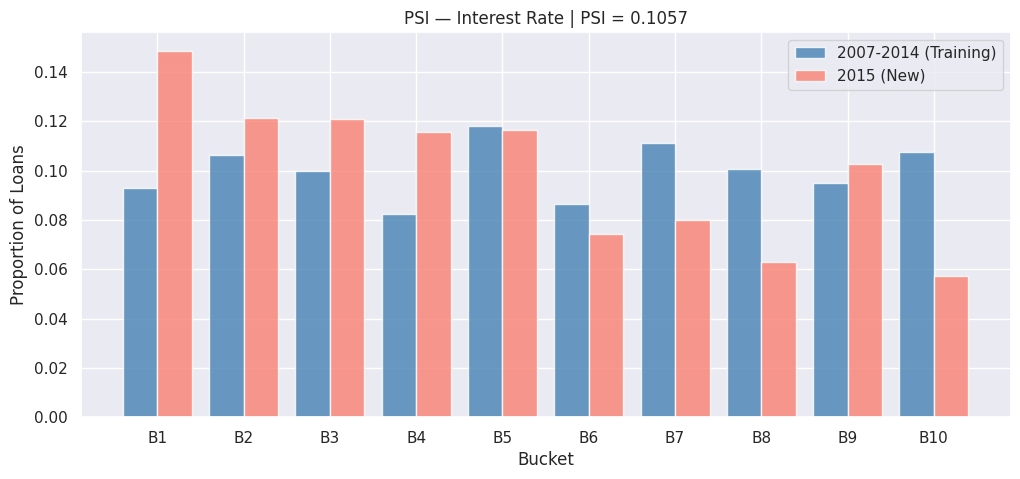

In [101]:
# Visualise PSI for a key variable - int_rate
expected = loan_data_inputs_train['int_rate'].dropna().values
actual   = loan_data_2015['int_rate'].dropna().values
psi_val, exp_pct, act_pct, bins = psi(expected, actual, n_bins=10)

bucket_labels = [f"B{i+1}" for i in range(len(exp_pct))]
x = np.arange(len(bucket_labels))

plt.figure(figsize=(12, 5))
plt.bar(x - 0.2, exp_pct, 0.4, label='2007-2014 (Training)', color='steelblue', alpha=0.8)
plt.bar(x + 0.2, act_pct, 0.4, label='2015 (New)',           color='salmon',    alpha=0.8)
plt.xticks(x, bucket_labels)
plt.xlabel('Bucket'); plt.ylabel('Proportion of Loans')
plt.title(f'PSI — Interest Rate | PSI = {psi_val:.4f}')
plt.legend()
plt.show()


In [102]:
# Final summary table of all PSI results
all_psi = pd.concat([psi_df, psi_cont_df], ignore_index=True)
all_psi = all_psi.sort_values('PSI', ascending=False)
print("\n📊 FULL PSI MONITORING REPORT")
print("=" * 50)
print(all_psi.to_string(index=False))
print()
print("Legend:")
print("  ✅ PSI < 0.10  — Population stable, model valid")
print("  ⚠️ PSI 0.10–0.25 — Moderate shift, monitor closely")
print("  🚨 PSI > 0.25  — Significant shift, consider rebuilding model")



📊 FULL PSI MONITORING REPORT
                   Variable      PSI     Status
         mths_since_issue_d 4.948900  🚨 Rebuild
        initial_list_status 0.333717  🚨 Rebuild
                   int_rate 0.105700 ⚠️ Monitor
                        dti 0.056100   ✅ Stable
             inq_last_6mths 0.051300   ✅ Stable
        verification_status 0.048219   ✅ Stable
                    purpose 0.045976   ✅ Stable
                funded_amnt 0.013500   ✅ Stable
             home_ownership 0.006922   ✅ Stable
                      grade 0.006775   ✅ Stable
mths_since_earliest_cr_line 0.005800   ✅ Stable
                 annual_inc 0.005500   ✅ Stable

Legend:
  ✅ PSI < 0.10  — Population stable, model valid
  ⚠️ PSI 0.10–0.25 — Moderate shift, monitor closely
  🚨 PSI > 0.25  — Significant shift, consider rebuilding model


---
# Summary

In this project, we built a complete **Credit Risk Expected Loss model** - exactly what a Credit Risk Analyst does in a bank or fintech:

| What we did | Why it matters |
|---|---|
| **Data Preparation** | Cleaned raw loan data, created dummy variables, handled missing values |
| **WoE & IV Analysis** | Identified which variables predict default, grouped categories intelligently |
| **PD Model (Logistic Regression)** | Predicted probability of default for each borrower |
| **Credit Scorecard** | Converted model output into business-friendly scores |
| **LGD Model (Two-stage)** | Estimated how much is lost when a loan defaults |
| **EAD Model (Linear Regression)** | Estimated outstanding balance at time of default |
| **Expected Loss** | Combined PD × LGD × EAD to get portfolio-level risk estimate |
| **PSI Monitoring** | Checked if the model is still valid on new 2015 data |

**Files needed to run this notebook:**
- `loan_data_2007_2014.csv`
- `loan_data_2015.csv`
